# CONFLUENCE Tutorial - 3: Lumped Basin Workflow (Tuolumne River at Yosemite)

## Introduction

## Lumped Basin Modeling Philosophy
Lumped basin modeling treats the entire watershed as one homogeneous computational unit, spatially averaging all variability across the catchment. This approach establishes baseline performance by determining whether a model can capture fundamental watershed response before adding spatial complexity, while its simplified parameter structure facilitates clear understanding of which parameters control model behavior and hydrological processes.

## Case Study: Tuolumne River at Yosemite
Here, we focus on the Tuolumne River at Yosemite watershed, located in the Sierra Nevada of California, US. This watershed encompasses approximately *1,958* km² with elevations ranging from *3,500* m at the outlet to over *8,600* m in the headwaters, representing a snow-dominated mountain system with pronounced seasonal cycles. The basin is monitored by USGS station 11290000, which provides long-term streamflow observations essential for model validation.

## Step 1: Basin-Scale Workflow Setup
Building on the point-scale modeling expertise from Tutorials 01a and 01b, we now advance to basin-scale hydrological modeling. This represents a scaling transition from process validation at individual sites to integrated watershed simulation that captures the collective hydrological response of an entire catchment.

The same CONFLUENCE architecture seamlessly handles this transition, demonstrating the framework's scalability from point validation through basin-scale prediction while maintaining reproducible workflow principles.

In [1]:
import os
# change to CONFLUENCE root directory
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [2]:
# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# import custom utility functions
from utils.custom.calc import *
from utils.custom.plotting import *
from utils.custom.adjust_settings import *

# Set up plotting style
plt.style.use('default')
%matplotlib inline

In [3]:
today = datetime.today().strftime('%Y%m%d')
relevant_detail = 'spongy_parkingLot'  # Update this based on the specific model configuration (e.g., 'lumped', 'semi_distributed')
name = f'{today}_{relevant_detail}'
# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED TUOLUMNE RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for semi-distributed modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed Tuolumne River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'Tuolumne_River_lumped',
    'EXPERIMENT_ID': f'{name}',  # Update experiment ID
    'DOMAIN_DEFINITION_METHOD': 'lumped',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Lumped',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2011-10-01 00:00',
    'EXPERIMENT_TIME_END':  '2022-09-30 23:00',
    'CALIBRATION_PERIOD': '2013-10-01, 2015-09-30',
    'EVALUATION_PERIOD': '2015-10-01, 2018-09-30',
    'SPINUP_PERIOD': '2011-10-01, 2013-09-30',
    'MPI_PROCESSES': 4,                       # Adjust based on available resources
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'DELINEATION_METHOD': 'TauDEM',  # Changed from 'TauDEM'
    'CATCHMENT_SHP_HRUID': 'HRU_ID',          # Updated HRU ID field
    'CATCHMENT_SHP_GRUID': 'GRU_ID',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
    'ROUTING_DELINEATION': 'lumped',        # Changed to 'lumped' or remove
    'APPLY_LAPSE_RATE': False,                 # Changed to True to apply lapse rate
    'OPTIMIZATION_METRIC': 'NSE',          # Changed to 'NSE' for emulation
    'ITERATIVE_OPTIMIZATION_ALGORITHM': 'DDS',  # Changed to 'DDS' for optimization
    'NUMBER_OF_ITERATIONS': 12,
    'BASIN_PARAMS_TO_CALIBRATE': 'basin__aquiferScaleFactor, basin__aquiferHydCond',
    'PARAMS_TO_CALIBRATE': 'k_soil, theta_sat, theta_res, aquiferScaleFactor, rootingDepth',
    'SUMMA_RUNOFF_VAR': 'scalarTotalRunoff'    # Use scalarTotalRunoff for calibration (not averageRoutedRunoff)
}

config_dict.update(config_updates)

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne_lumped_v1.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")
print(f"Basin Parameters to Calibrate: {confluence.config['BASIN_PARAMS_TO_CALIBRATE']}")

2026-02-25 16:05:51 ● CONFLUENCE Logging Initialized
2026-02-25 16:05:51 ● Domain: Tuolumne_River_lumped
2026-02-25 16:05:51 ● Experiment ID: 20260225_spongy_parkingLot
2026-02-25 16:05:51 ● Log Level: INFO
2026-02-25 16:05:51 ● Log File: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/_workLog_Tuolumne_River_lumped/confluence_general_Tuolumne_River_lumped_20260225_160551.log


2026-02-25 16:05:51 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/_workLog_Tuolumne_River_lumped/config_Tuolumne_River_lumped_20260225_160551.yaml
2026-02-25 16:05:51 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
2026-02-25 16:05:51 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_Tuolumne_lumped_v1.yaml
=== Directory Configuration ===
Code Directory: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
Data Directory: /scratch/dlhogan/ess-project-data

=== Key Configuration Settings ===
Domain Name: Tuolumne_River_lumped
Pour Point: 37.91657698/-119.6598627
Spatial Mode: Lumped
Model: SUMMA
Simulation Period: 2011-10-01 00:00 to 2022-09-30 23:00
Basin Parameters to Calibrate: basin__aquiferScaleFactor, basin__aquiferHydCond


### Model Decision & Parameter Changes

In [5]:
# =============================================================================
# PARAMETER AND MODEL DECISION SETUP
# =============================================================================
from utils.custom.adjust_settings import edit_modelDecisions, update_and_reformat_parameter_file

# Define base settings paths (READ ONLY - do not modify!)
base_settings_dir = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA")

# Define working copy directory in scratch
project_settings_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "settings" / "SUMMA"
project_settings_dir.mkdir(parents=True, exist_ok=True)

# ============= STEP 1: Copy base settings to scratch directory =============
# IMPORTANT: Always work with copies, never modify base settings!
print("📋 Copying base settings to working directory...")
shutil.copy(base_settings_dir / "modelDecisions.txt", project_settings_dir / "modelDecisions.txt")
shutil.copy(base_settings_dir / "localParamInfo.txt", project_settings_dir / "localParamInfo.txt")
shutil.copy(base_settings_dir / "basinParamInfo.txt", project_settings_dir / "basinParamInfo.txt")
print(f"   ✓ Base settings copied to: {project_settings_dir}")

# Define working file paths (in scratch directory)
modelDecision_file = project_settings_dir / "modelDecisions.txt"
localParamInfo_file = project_settings_dir / "localParamInfo.txt"
basinParamInfo_file = project_settings_dir / "basinParamInfo.txt"

# ============= STEP 2: Update Model Decisions =============
modelDecision_updates = {
    'groundwatr': 'bigBuckt',
    'bcLowrSoiH': 'drainage',
    'spatial_gw': 'localColumn',
    'alb_method': 'varDecay'
}

edit_modelDecisions(modelDecision_file, modelDecision_updates)
print("✓ Updated model decisions")

# ============= STEP 3: Choose Parameter Update Workflow =============
# CHOOSE ONE:
# ─────────────────────────────────────────────────────────────────────────────
USE_OPTIMIZATION_PARAMETERS = False  # Set to True to use calibrated best parameters
USE_MANUAL_PARAMETERS = True  # Set to True to use manually specified parameter values
USE_OLD_PARAMETERS = False  # Set to True to use old parameter values (no updates)
# ─────────────────────────────────────────────────────────────────────────────

if USE_OPTIMIZATION_PARAMETERS:
    # WORKFLOW A: Use best parameters from optimization + reformat
    print("\n📊 Using best parameters from optimization run...")
    
    # Find and read best_parameters.csv
    opt_base_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "optimisation"
    opt_dirs = sorted([d for d in opt_base_dir.iterdir() if d.is_dir()], 
                     key=lambda x: x.stat().st_mtime, reverse=True)
    
    if opt_dirs:
        best_params_csv = opt_dirs[0] / "best_parameters.csv"
        if best_params_csv.exists():
            best_params_df = pd.read_csv(best_params_csv)
            best_params_dict = dict(zip(best_params_df['parameter'], best_params_df['value']))
            print(f"   Found {len(best_params_dict)} optimized parameter values")    
            # ============= STEP 4: Update parameters in scratch copies =============
            print("\n📝 Updating parameter files with 4-decimal precision formatting...")

            # Update local parameters
            local_updates = {k: v for k, v in best_params_dict.items() 
                            if not k.startswith('basin__') and not k.startswith('routing')}
            update_and_reformat_parameter_file(localParamInfo_file, 
                                                local_updates, reformat_all=True, verbose=True)

            # Update basin parameters
            basin_updates = {k: v for k, v in best_params_dict.items() 
                            if k.startswith('basin__') or k.startswith('routing')}
            update_and_reformat_parameter_file(basinParamInfo_file, 
                                                basin_updates, reformat_all=True, verbose=True)
        else:
            print("   ⚠ best_parameters.csv not found, using manual edits instead")
            USE_OPTIMIZATION_PARAMETERS = False
    else:
        print("   ⚠ No optimization results found, using manual edits instead")
        USE_OPTIMIZATION_PARAMETERS = False

elif USE_MANUAL_PARAMETERS:
    # WORKFLOW B: Use manual parameter edits only
    print("\n✏️  Using manually specified parameter values...")
    
    # Manual parameter updates - these override defaults
    localParamInfo_updates = {
        'tempCritRain': 274.1000,
        'k_soil': 9.4e-6,
        'theta_sat': 0.5160,
        'theta_res': 0.0270,
        'rootingDepth': 6.876,
    }
    
    basinParamInfo_updates = {
        "basin__aquiferHydCond": 0.0010,
        "basin__aquiferScaleFactor": 50.0000,
        "routingGammaShape": 2.5000,
        "routingGammaScale": 4.6e4,
    }
    
    best_params_dict = {**localParamInfo_updates, **basinParamInfo_updates}
    print(f"   Using {len(best_params_dict)} manual parameter values")
        # ============= STEP 4: Update parameters in scratch copies =============
    print("\n📝 Updating parameter files with 4-decimal precision formatting...")

    # Update local parameters
    local_updates = {k: v for k, v in best_params_dict.items() 
                    if not k.startswith('basin__') and not k.startswith('routing')}
    update_and_reformat_parameter_file(localParamInfo_file, 
                                        local_updates, reformat_all=True, verbose=True)

    # Update basin parameters
    basin_updates = {k: v for k, v in best_params_dict.items() 
                    if k.startswith('basin__') or k.startswith('routing')}
    update_and_reformat_parameter_file(basinParamInfo_file, 
                                        basin_updates, reformat_all=True, verbose=True)
else:
    # WORKFLOW C: Use old parameters (no updates)
    print("\n⏪ Using old parameter values (no updates)")
    run_date = input("Enter the date of the original run to use parameters from (YYYYMMDD): ")
    # Find to the original parameters 
    old_params_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "simulations" / f"{run_date}_{relevant_detail}" / "parameters"
    # copy the files to the current settings directory
    shutil.copy(old_params_dir / "localParamInfo.txt", localParamInfo_file)
    shutil.copy(old_params_dir / "basinParamInfo.txt", basinParamInfo_file)
    print(f"   Copied old parameter files from {old_params_dir} to {project_settings_dir}")
    # No further updates needed, so we can exit here


print(f"\n✓ All settings synced to: {project_settings_dir}")
print(f"✓ Base settings in {base_settings_dir} remain unchanged")

📋 Copying base settings to working directory...
   ✓ Base settings copied to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/settings/SUMMA
✓ Updated model decisions

✏️  Using manually specified parameter values...
   Using 9 manual parameter values

📝 Updating parameter files with 4-decimal precision formatting...
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision

✓ All settings synced to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/settings/SUMMA
✓ Base settings in /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA remain unchanged


In [6]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

2026-02-25 16:06:20 ● Setting up project for domain: Tuolumne_River_lumped
2026-02-25 16:06:20 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped
2026-02-25 16:06:20 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/pour_point/Tuolumne_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_Tuolumne_River_lumped
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 parameters
  📁 plots
  📁 settings
  📁 shapefiles
  📁 simulations

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Step 2: Basin Representation and Spatial Discretization Fundamentals
The transition from point-scale to basin-scale modeling requires fundamental decisions about how to represent spatial heterogeneity within the watershed. Unlike point-scale modeling where we assume uniform conditions, basin-scale modeling must address the challenge of capturing spatial variability.

### Scientific Context: Basin Representation Philosophy
Basin-scale hydrological modeling confronts significant spatial heterogeneity challenges that profoundly influence water cycling processes. 
- Elevation gradients create complex patterns in temperature lapse rates, precipitation distributions, and snow line dynamics that control seasonal water storage and release. 
- Vegetation patterns ranging from dense forest to alpine zones fundamentally alter evapotranspiration rates and interception processes. 
- Soil variability across the landscape affects infiltration capacity, water storage potential, and drainage characteristics that determine runoff generation mechanisms. 
- Topographic effects including slope, aspect, and drainage network configuration control flow routing and energy balance processes. 
- Climate gradients manifest through orographic precipitation enhancement, temperature inversions, and wind pattern modifications that create substantial spatial variability in hydrological drivers.

### Representation Strategies and Discretization Approaches
Hydrological modeling addresses these spatial complexities through three primary representation strategies, each offering distinct advantages and computational trade-offs. 
- The lumped approach treats the entire watershed as a single computational unit with spatially-averaged characteristics, providing computational efficiency and parameter interpretability while sacrificing spatial detail. 
- Semi-distributed strategies create multiple computational units based on landscape similarity criteria such as elevation bands, soil types, or land cover classes, balancing spatial representation with computational tractability. 
- Fully distributed approaches employ grid-based representation with explicit spatial patterns, capturing detailed heterogeneity at the cost of increased computational demands and parameter complexity.

The Grouped Response Unit (GRU) concept provides flexible spatial discretization that allows users to choose the appropriate level of complexity for their scientific objectives and computational constraints. This framework enables seamless transitions from lumped representations through increasingly detailed semi-distributed configurations, ensuring that model complexity aligns with both scientific questions and available computational resources.

In [7]:
# Execute attribute acquisition
# confluence.managers['data'].acquire_attributes()
print("✅ Basin-scale attribute acquisition complete")

✅ Basin-scale attribute acquisition complete


In [8]:
# Execute watershed delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Watershed delineation complete")

# Execute domain discretization
confluence.managers['domain'].discretize_domain()
print("✅ Domain discretization complete")


2026-02-25 16:06:21 ● Domain definition workflow starting with: lumped
2026-02-25 16:06:21 ● Starting lumped watershed delineation for Tuolumne_River_lumped


PitRemove version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif has geographic coordinate system.
Nodata value input to create partition from file: -9999.000000
Nodata value recast to float used in partition raster: -9999.000000
Processes: 4
Header read time: 0.037674
Data read time: 0.002675
Compute time: 0.032688
Write time: 0.018686
Total time: 0.091723
2026-02-25 16:06:22 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/fel.tif


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

D8FlowDir version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/fel.tif has geographic coordinate system.
Nodata value input to create partition from file: -300000000549775575777803994281145270272.000000
Nodata value recast to float used in partition raster: -300000000549775575777803994281145270272.000000
Processors: 4
Header read time: 0.038927
Data read time: 0.011758
Compute Slope time: 0.024467
Write Slope time: 0.023069
Resolve Flat time: 0.083843
Write Flat time: 0.008322
Total time: 0.190386


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

...

MoveOutletsToStreams version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/src.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
om Total time: 0.078143
2026-02-25 16:06:25 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/moveoutletstostrm -p /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif -src /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/src.tif -o /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/pour_point/Tuolumne_River_lumped_pourPoint.s

ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: 

Gage Watershed version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Size: 4
Read time: 0.056850
Compute time: 0.011629
Write time: 0.004451
Total time: 0.072930
2026-02-25 16:06:25 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/gagewatershed -p /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/p.tif -o /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/om.shp -gw /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/watershed.tif -id /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir/watershed_id.txt
2026-02-25 16:06:25 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river

ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

2026-02-25 16:06:25 ● Updated watershed shapefile at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped.shp
2026-02-25 16:06:25 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/tempdir
2026-02-25 16:06:25 ● Created river network shapefile at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_network/Tuolumne_River_lumped_riverNetwork_lumped.shp
2026-02-25 16:06:25 ● Updated river basins shapefile with required fields at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped.shp
2026-02-25 16:06:25 ● Updated river network shapefile with required fields at: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_network/Tuolumne_River_lumped_riverNetwork_lumped.shp
2026-02-25 16:06:25 ● Domain definition completed using method: 

## VISUALIZATION AND ANALYSIS OF BASIN REPRESENTATION


📋 Basin Characteristics:
   Watershed area: 774.5 km²
   Number of GRUs: 1
   Average GRU size: 774.5 km²

🗺️  Creating basin representation visualization...


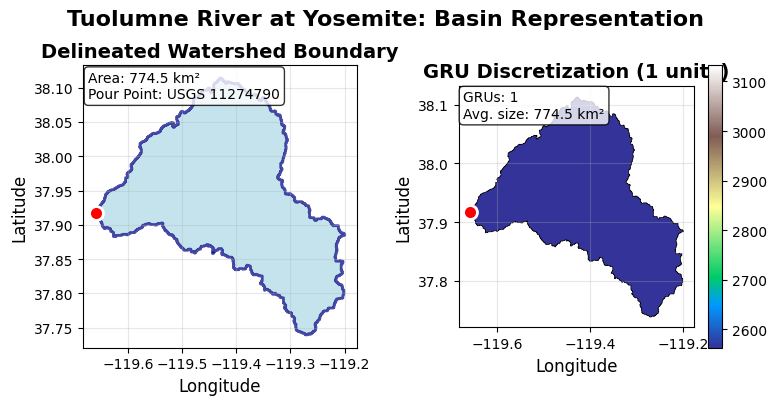

In [32]:
# Load spatial data
hru_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'shapefiles' / 'catchment' / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp")
watershed_gdf = gpd.read_file(str(watershed_path[1]))
hru_gdf = gpd.read_file(hru_path).iloc[1:]  # Skip first row if it's a dummy HRU
pour_point_gdf = gpd.read_file(pour_point_path)

# Project to appropriate CRS for area calculations
# For Tuolumne River at Yosemite (Alberta), UTM Zone 11N is appropriate
target_crs = 'EPSG:32611'  # UTM Zone 11N
watershed_projected = watershed_gdf.to_crs(target_crs)
hru_projected = hru_gdf.to_crs(target_crs)

print(f"\n📋 Basin Characteristics:")
total_area_m2 = watershed_projected.geometry.area.sum()
total_area_km2 = total_area_m2 / 1e6
print(f"   Watershed area: {total_area_km2:.1f} km²")
print(f"   Number of GRUs: {len(hru_gdf)}")
print(f"   Average GRU size: {total_area_km2/len(hru_gdf):.1f} km²")

# Display HRU characteristics if available
if 'elevation' in hru_gdf.columns:
    print(f"   Elevation range: {hru_gdf['elevation'].min():.0f}m to {hru_gdf['elevation'].max():.0f}m")
if 'slope' in hru_gdf.columns:
    print(f"   Slope range: {hru_gdf['slope'].min():.1f}° to {hru_gdf['slope'].max():.1f}°")

# Create comprehensive visualization
print(f"\n🗺️  Creating basin representation visualization...")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left plot: Watershed boundary and pour point (use original CRS for plotting)
ax1 = axes[0]
watershed_gdf.plot(ax=ax1, facecolor='lightblue', edgecolor='navy', 
                  linewidth=2, alpha=0.7)
pour_point_gdf.plot(ax=ax1, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax1.set_title('Delineated Watershed Boundary', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add area annotation
ax1.text(0.02, 0.98, f'Area: {total_area_km2:.1f} km²\nPour Point: USGS {config_dict["STATION_ID"]}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

# Right plot: HRU discretization
ax2 = axes[1]
# Color HRUs by elevation if available, otherwise by area (using projected areas)
if 'elev_mean' in hru_gdf.columns:
    hru_gdf.plot(ax=ax2, column='elev_mean', cmap='terrain', 
                edgecolor='black', linewidth=0.5, legend=True)
    colorbar_label = 'Elevation (m)'
else:
    # Use projected geometries for area calculation
    hru_areas_km2 = hru_projected.geometry.area / 1e6
    hru_gdf.plot(ax=ax2, column=hru_areas_km2, cmap='viridis',
                edgecolor='black', linewidth=0.5, legend=True) 
    colorbar_label = 'Area (km²)'

pour_point_gdf.plot(ax=ax2, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax2.set_title(f'GRU Discretization ({len(hru_gdf)} units)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add discretization info
ax2.text(0.02, 0.98, f'GRUs: {len(hru_gdf)}\nAvg. size: {total_area_km2/len(hru_gdf):.1f} km²',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

plt.suptitle(f'Tuolumne River at Yosemite: Basin Representation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Data Pipeline for Basin-Scale Streamflow Modeling
The same model-agnostic preprocessing framework now scales from point validation to basin-scale streamflow simulation. The core philosophy remains unchanged—standardized, quality-controlled data products—but the spatial context shifts from single locations to integrated watershed responses

In [10]:
# =============================================================================
# FORCING DATA PROCESSOR - Using reusable module
# =============================================================================
from utils.custom.forcing_processor import ForcingProcessor

# Initialize the forcing processor with config
forcing_processor = ForcingProcessor(config_dict)

# Check current status of forcing data
status = forcing_processor.check_status()

FORCING DATA STATUS

Required period: 2011-10 to 2022-09
Required months: 132

📁 Raw ERA5 surface files: 540
📁 Raw ERA5 pressure files: 540

📁 Merged files: 171
   Range: 201010 to 202412

📁 Basin-averaged files: 171
   Range: 201010 to 202412

📁 SUMMA input files: 171
   Range: 201010 to 202412

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 0


In [11]:
# =============================================================================
# STEP 3a: MERGE RAW ERA5 DATA (Surface + Pressure Level)
# =============================================================================
# Combines ERA5_surface_YYYYMM.nc + ERA5_pressureLevel137_YYYYMM.nc into ERA5_merged_YYYYMM.nc

forcing_processor.merge_era5()

✅ All merged files already exist


0

In [12]:
# =============================================================================
# STEP 3b: BASIN-AVERAGE MERGED DATA OVER CATCHMENT
# =============================================================================
# Uses CONFLUENCE's built-in EASYMORE resampler for spatial averaging

forcing_processor.basin_average(confluence=confluence)

✅ All basin-averaged files already exist


0

In [13]:
# =============================================================================
# STEP 3c: CREATE SUMMA INPUT (with optional adjustments)
# =============================================================================
# Optional: apply temperature offset and/or precipitation scaling

forcing_processor.create_summa_input(
    temp_adjustment=0.0,      # Kelvin offset (0 = no change)
    precip_multiplier=1.0,     # Scaling factor (1.0 = no change)
    recalc_longwave=True
)

# Verify final status
forcing_processor.check_status()

✅ All SUMMA input files already exist
FORCING DATA STATUS

Required period: 2011-10 to 2022-09
Required months: 132

📁 Raw ERA5 surface files: 540
📁 Raw ERA5 pressure files: 540

📁 Merged files: 171
   Range: 201010 to 202412

📁 Basin-averaged files: 171
   Range: 201010 to 202412

📁 SUMMA input files: 171
   Range: 201010 to 202412

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 0


{'required_period': '2011-10 to 2022-09',
 'required_months': 132,
 'raw_surface_count': 540,
 'raw_pressure_count': 540,
 'merged_count': 171,
 'basin_avg_count': 171,
 'summa_input_count': 171,
 'missing_merged': [],
 'missing_basin_avg': [],
 'missing_summa': []}

### Observed data

In [14]:
# Execute streamflow data processing
# confluence.managers['data'].process_observed_data()
print("✅ Streamflow data processing complete")

# NOTE: Forcing acquisition/processing is handled in cells above (Step 3a-3c)
# confluence.managers['data'].acquire_forcings()  # Skipped - forcing already processed
print("✅ Forcing data prepared via manual processing above")

✅ Streamflow data processing complete
✅ Forcing data prepared via manual processing above


### Model Agnostic preprocessing

In [15]:
# Execute model-agnostic preprocessing
confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Model-agnostic preprocessing complete")

2026-02-25 16:06:30 ● Starting model-agnostic preprocessing
2026-02-25 16:06:30 ● Running geospatial statistics
2026-02-25 16:06:30 ● Starting geospatial statistics calculation
2026-02-25 16:06:30 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
2026-02-25 16:06:30 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
2026-02-25 16:06:30 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
2026-02-25 16:06:30 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
2026-02-25 16:06:30 ● Running forcing resampling
2026-02-25 16:06:30 ● Starting forcing data resampling process
2026-02-25 16:06:30 ● Creati

In [16]:
# =============================================================================
# PROTECT CUSTOM PARAMETER FILES BEFORE PREPROCESSING
# =============================================================================
# IMPORTANT: Backup custom parameter files before model preprocessing,
# because confluence.managers['model'].preprocess_models() calls
# copy_base_settings() which would overwrite our custom configurations!

print("🔒 Backing up custom parameter files before preprocessing...")
backup_dir = project_settings_dir / "backup_custom_config"
backup_dir.mkdir(parents=True, exist_ok=True)

# Backup the three critical parameter files
critical_files = [
    "modelDecisions.txt",
    "localParamInfo.txt", 
    "basinParamInfo.txt"
]

for fname in critical_files:
    src = project_settings_dir / fname
    dst = backup_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Backed up {fname}")
    else:
        print(f"   ⚠ {fname} not found (will be created during preprocessing)")

# ============= Execute model-specific preprocessing =============
# This step will copy base settings and create forcing files, initial conditions, etc.
# But it WILL overwrite our custom parameter files, so we backed them up above!
confluence.managers['model'].preprocess_models()
print("✅ Model-specific preprocessing complete")

# ============= RESTORE CUSTOM PARAMETER FILES AFTER PREPROCESSING =============
print("\n🔓 Restoring custom parameter files after preprocessing...")
for fname in critical_files:
    src = backup_dir / fname
    dst = project_settings_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Restored {fname}")

print(f"\n✓ Custom parameters protected and restored in {project_settings_dir}")
print(f"✓ Base settings remain unchanged in {base_settings_dir}")

🔒 Backing up custom parameter files before preprocessing...
   ✓ Backed up modelDecisions.txt
   ✓ Backed up localParamInfo.txt
   ✓ Backed up basinParamInfo.txt
2026-02-25 16:06:30 ● Starting model-specific preprocessing
2026-02-25 16:06:30 ● Starting SUMMA spatial preprocessing
2026-02-25 16:06:30 ● Starting memory-efficient temperature lapse rate and data step application
2026-02-25 16:06:30 ● Loading topology data...
2026-02-25 16:06:30 ● Loaded topology data: 6 rows, 0.06 MB
2026-02-25 16:06:30 ● Found 171 forcing files to process


2026-02-25 16:06:30 ● Pre-calculating lapse rate corrections...
2026-02-25 16:06:31 ● Prepared lapse corrections for 1 HRUs
2026-02-25 16:06:31 ● Processing files in batches of 100
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201010.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201011.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201012.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201101.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201102.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File Tuolumne_River_lumped_ERA5_remapped_ERA5_merged_201103.nc: Removing 1 HRU IDs without lapse values: [2.]
2026-02-25 16:06:31 ● File 

#### No longer really needed.
This is the manual update to the forcing files

In [17]:
# open the dem 
dem_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'attributes' / 'elevation' / "dem" / "domain_Tuolumne_River_lumped_elv.tif")

# using rasterio open the dem
import rasterio
with rasterio.open(dem_path) as dem_src:
    dem_data = dem_src.read(1)  # Read the first band
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

# calculate the mean elevation
mean_elevation = np.nanmean(dem_data)

# adjust temperature by difference between mean dem elevation and mean hru elevation
mean_hru_elevation = hru_gdf['elev_mean'].mean()
elevation_difference = mean_hru_elevation - mean_elevation
lapse_rate = 6.5 / 1000  # °C per meter
temperature_adjustment = elevation_difference * lapse_rate

# winter adjustment (Jan - May)
monthly_adjustment = {
    1: 1.0,  # January
    2: 1.0,  # February
    3: 1.0,  # March
    4: 1.0,  # April
    5: 1.0,  # May
    6: 0.0,  # June
    7: -1.0,  # July
    8: -1.0,  # August
    9: -1.0,  # September
    10: -1.0, # October
    11: -1.0, # November
    12: 0.0  # December
}

In [18]:
file_list = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(f"domain_{config_dict['DOMAIN_NAME']}/forcing/forcing_noTadjust/{config_dict['DOMAIN_NAME']}_ERA5_remapped_ERA5_merged_*.nc"))
file_list = sorted(file_list)
for file in file_list:
    ds = xr.open_dataset(str(file))
    # adjust temperature
    ds['airtemp'] = ds['airtemp'] + temperature_adjustment
    # determe additional monthly temperature adjustment
    # monthlyTempAdjustment = monthly_adjustment[ds['airtemp'].time.dt.month.values[0]]
    # ds['airtemp'] = ds['airtemp'] + monthlyTempAdjustment
    # adjust precipitation
    # ds['pptrate'] = ds['pptrate'] * 0.90  # Example: decrease precipitation by 10%
    # recalculate incoming longwave radiation using empirical formula
    ds['LWRadAtm'] = empirical_lw_dilley_obrien(ds['airtemp'], ds['spechum'], ds['airpres'])
    # save the modified dataset back to new file
    adjusted_file_path = str(file).replace("forcing_noTadjust", "SUMMA_input")
    ds.to_netcdf(adjusted_file_path)
    ds.close()

## Step 4: Streamlined Basin-Scale Model Execution
The same SUMMA process-based physics now scales from point validation to integrated basin simulation, but with the critical addition of streamflow routing. This represents a fundamental modeling advancement: from isolated vertical processes to coupled vertical-horizontal water transport that generates streamflow at the basin outlet.

#### Step 4b: Model Calibration Optimization

In [19]:
confluence.managers['optimization'].calibrate_model()

2026-02-25 16:06:57 ● Starting model calibration
2026-02-25 16:06:57 ● Using DDS optimization
2026-02-25 16:06:57 ● Using spinup + calibration period: 2011-10-01 01:00 to 2015-09-30 23:00
2026-02-25 16:06:57 ● Setting up parallel processing with 4 processes
2026-02-25 16:06:57 ● Starting DDS optimization for streamflow calibration
2026-02-25 16:06:57 ● Target metric: NSE
2026-02-25 16:06:57 ● Max iterations: 12
2026-02-25 16:06:57 ● Parallel processing: 4 processes
2026-02-25 16:06:57 ● Running DDS algorithm
2026-02-25 16:06:57 ● Initializing DDS with single solution
2026-02-25 16:06:57 ● Evaluating initial solution...


2026-02-25 16:08:02 ● Using config-specified SUMMA_RUNOFF_VAR: scalarTotalRunoff
2026-02-25 16:08:02 ● Initial solution evaluated. Score: -1.750035
2026-02-25 16:08:02 ● Multi-start parallel DDS: 4 instances
2026-02-25 16:08:02 ● Iterations per instance: 3
2026-02-25 16:08:02 ● Starting parallel DDS instances...
2026-02-25 16:08:02 ● Starting 4 DDS workers with 4 processes


[DDS-00] INFO: Starting DDS instance 0 with 3 iterations
[DDS-02] INFO: Starting DDS instance 2 with 3 iterations
[DDS-01] INFO: Starting DDS instance 1 with 3 iterations
[DDS-03] INFO: Starting DDS instance 3 with 3 iterations
[P00-I000] INFO: Starting evaluation of individual 0
[P00-I000] INFO: Multi-objective evaluation: False
[P00-I000] INFO: Needs routing: False
[P00-I000] INFO: Applying parameters
[P00-I000] DEBUG: Applying parameters: ['k_soil', 'theta_sat', 'theta_res', 'aquiferScaleFactor', 'rootingDepth', 'basin__aquiferScaleFactor', 'basin__aquiferHydCond'] (consistent method)
[P00-I000] DEBUG: Generating trial parameters file with: ['k_soil', 'theta_sat', 'theta_res', 'aquiferScaleFactor', 'rootingDepth', 'basin__aquiferScaleFactor', 'basin__aquiferHydCond'] (consistent)
[P00-I000] DEBUG: Attempt 1: Writing trial parameters to /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/simulations/run_dds/parallel_proc_00/settings/SUMMA/trialParams.tmp_299591_4049
[P00-I

2026-02-25 16:09:57 ● DDS instance 2 completed: -1.218460


[P00-I000] ERROR: SUMMA simulation failed with exit code 1
[P00-I000] ERROR: SUMMA simulation failed
[DDS-03] WARNING: Evaluation failed: SUMMA simulation failed
[DDS-03] INFO: DDS instance 3 completed: Best=-0.743474, Evaluations=4


...

[P00-I000] INFO: SUMMA execution completed successfully. Output files: 1 timestep files
[P00-I000] INFO: Single-objective evaluation using inline calculation
[P00-I000] INFO: DEBUG: Starting inline metrics calculation
[P00-I000] INFO: DEBUG: SUMMA dir: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/simulations/run_dds/parallel_proc_01/SUMMA
[P00-I000] INFO: DEBUG: mizuRoute dir: None
[P00-I000] INFO: DEBUG: SUMMA dir exists: True
[P00-I000] INFO: DEBUG: mizuRoute dir exists: None
[P00-I000] INFO: DEBUG: Found 1 SUMMA timestep files
[P00-I000] INFO: DEBUG: SUMMA file: proc_01_dds_opt_20260225_spongy_parkingLot_timestep.nc
[P00-I000] INFO: DEBUG: Using SUMMA files (need m/s to m³/s conversion)
[P00-I000] DEBUG: Found basin shapefile: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/river_basins/Tuolumne_River_lumped_riverBasins_lumped.shp
[P00-I000] DEBUG: Looking for area column: GRU_area
[P00-I000] DEBUG: Available columns: ['ID', 'GRU_ID', 'gru

2026-02-25 16:10:30 ● DDS instance 1 completed: -0.827059


[DDS-00] INFO: DDS instance 0 completed: Best=-0.671542, Evaluations=4


2026-02-25 16:10:30 ● DDS instance 0 completed: -0.671542
2026-02-25 16:10:30 ● MULTI-START DDS SUMMARY
2026-02-25 16:10:30 ● Successful instances: 4/4 (100.0%)
2026-02-25 16:10:30 ● Best score across all: -0.671542
2026-02-25 16:10:30 ● Total parallel time: 147.6s
2026-02-25 16:10:30 ● Running final evaluation with best parameters
2026-02-25 16:10:30 ● mizuRoute control file not found: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/simulations/run_dds/settings/mizuRoute/mizuroute.control
2026-02-25 16:10:30 ● Parameter application successful
2026-02-25 16:13:14 ● Using config-specified SUMMA_RUNOFF_VAR: scalarTotalRunoff
2026-02-25 16:13:14 ● No common time indices for Eval period
2026-02-25 16:13:14 ● Final evaluation completed successfully
2026-02-25 16:13:14 ● FINAL EVALUATION RESULTS
2026-02-25 16:13:14 ● 📊 CALIBRATION PERIOD PERFORMANCE:
2026-02-25 16:13:14 ●    KGE: -0.099788
2026-02-25 16:13:14 ●    NSE: -1.750035
2026-02-25 16:13:14 ●    RMSE: 14.905959
2026-02

PosixPath('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/optimisation/20260225_spongy_parkingLot_parallel_iteration_results.csv')

### Analyzing Calibration Results & Parameter Sensitivity
After calibration completes, we analyze:
1. **Best Parameters** - The optimal parameter set found
2. **Convergence History** - How performance improved over iterations
3. **Parameter Sensitivity** - Which parameters most influence model performance

In [20]:
# =============================================================================
# LOAD AND ANALYZE OPTIMIZATION RESULTS
# =============================================================================

# Define paths to optimization outputs
opt_base_dir = project_dir / "optimisation"
experiment_id = config_dict['EXPERIMENT_ID']

# Find the most recent optimization results folders
dds_folders = sorted(opt_base_dir.glob("dds_*"))
history_files = sorted(opt_base_dir.glob("*_dds_history.csv"))

print("=" * 60)
print("CALIBRATION RESULTS ANALYSIS")
print("=" * 60)

# Load the DDS history (all iterations with parameters)
if history_files:
    latest_history_file = history_files[-1]
    dds_history = pd.read_csv(latest_history_file)
    print(f"\n📁 Loaded history from: {latest_history_file.name}")
    print(f"   Total iterations: {len(dds_history)}")
else:
    print("⚠️ No DDS history file found")
    dds_history = None

# Load best parameters from the optimization folder
if dds_folders:
    latest_dds_folder = dds_folders[-1]
    best_params_file = latest_dds_folder / "best_parameters.csv"
    opt_history_file = latest_dds_folder / "optimization_history.csv"
    
    if best_params_file.exists():
        best_params_df = pd.read_csv(best_params_file)
        print(f"\n✅ BEST PARAMETERS FOUND:")
        print("-" * 40)
        for _, row in best_params_df.iterrows():
            print(f"   {row['parameter']:20s}: {row['value']:.6g}")
        
    if opt_history_file.exists():
        opt_history_df = pd.read_csv(opt_history_file)
        best_score = opt_history_df['best_score'].max()
        best_gen = opt_history_df.loc[opt_history_df['best_score'].idxmax(), 'generation']
        print(f"\n📊 Best {config_dict.get('OPTIMIZATION_METRIC', 'NSE')}: {best_score:.4f} (Generation {best_gen})")

# Get the parameter columns (exclude iteration and metric)
if dds_history is not None:
    metric_col = config_dict.get('OPTIMIZATION_METRIC', 'NSE')
    param_cols = [c for c in dds_history.columns if c not in ['iteration', metric_col]]
    
    print(f"\n📋 Parameters calibrated: {len(param_cols)}")
    for p in param_cols:
        print(f"   - {p}")

CALIBRATION RESULTS ANALYSIS

📁 Loaded history from: 20260225_spongy_parkingLot_dds_history.csv
   Total iterations: 4

✅ BEST PARAMETERS FOUND:
----------------------------------------
   k_soil              : 5.58617e-06
   theta_sat           : 0.575481
   theta_res           : 0.07221
   aquiferScaleFactor  : 72.2679
   rootingDepth        : 8.81131
   basin__aquiferScaleFactor: 73.1425
   basin__aquiferHydCond: 0.725523

📊 Best NSE: -0.6715 (Generation 2)

📋 Parameters calibrated: 7
   - k_soil
   - theta_sat
   - theta_res
   - aquiferScaleFactor
   - rootingDepth
   - basin__aquiferScaleFactor
   - basin__aquiferHydCond


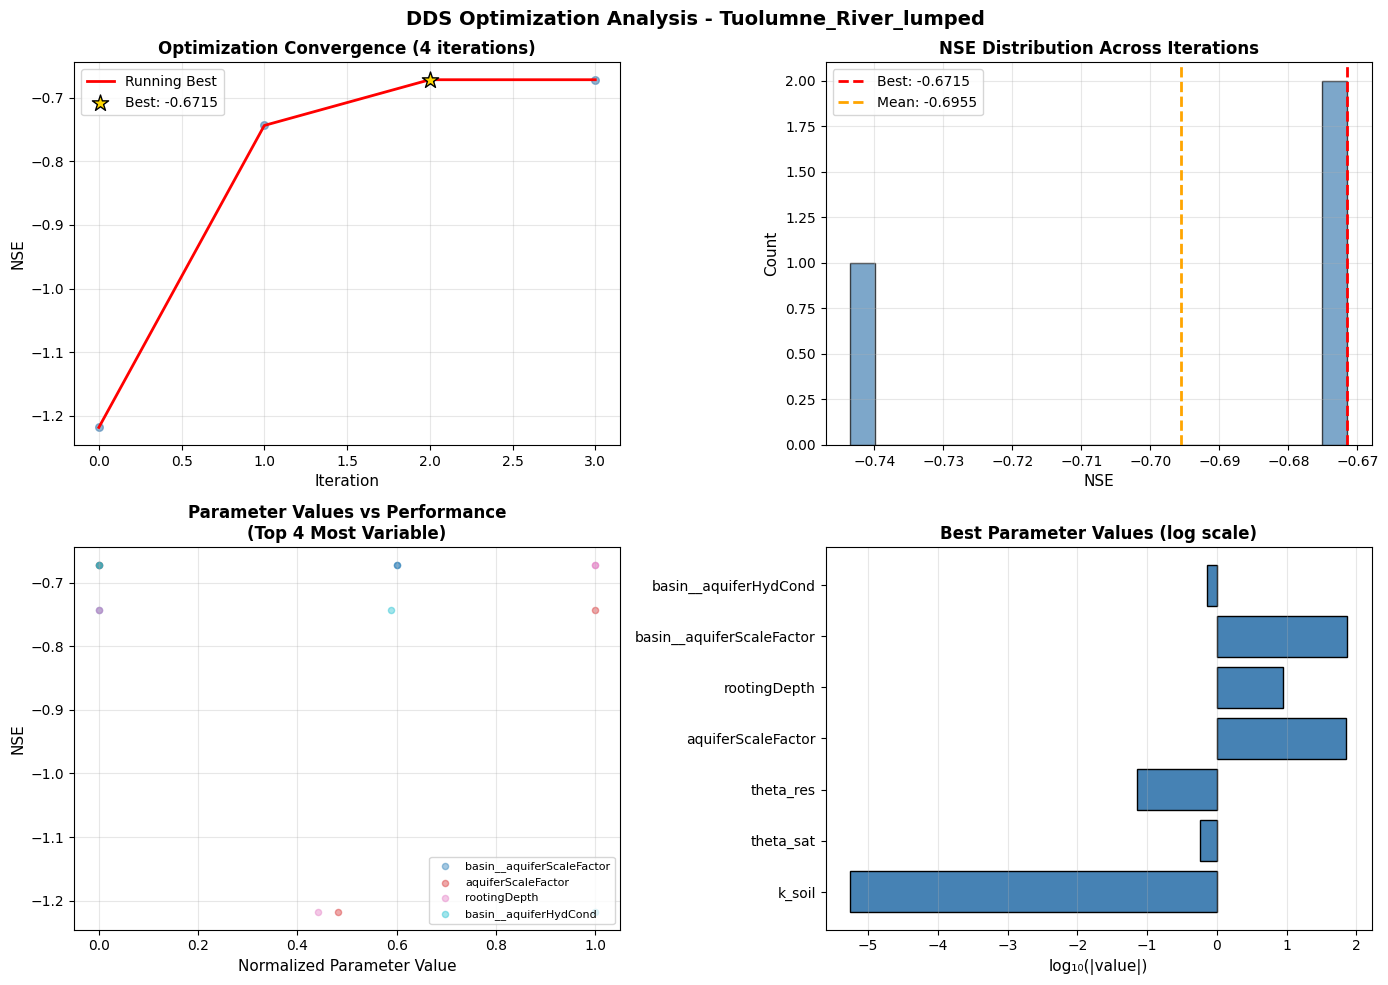

In [21]:
# =============================================================================
# VISUALIZATION 1: OPTIMIZATION CONVERGENCE
# =============================================================================

if dds_history is not None and len(dds_history) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metric_col = config_dict.get('OPTIMIZATION_METRIC', 'NSE')
    
    # 1. Convergence plot - all iterations
    ax1 = axes[0, 0]
    ax1.scatter(range(len(dds_history)), dds_history[metric_col], alpha=0.6, c='steelblue', s=30)
    
    # Running best line
    running_best = dds_history[metric_col].cummax()
    ax1.plot(range(len(dds_history)), running_best, 'r-', linewidth=2, label='Running Best')
    
    # Mark overall best
    best_idx = dds_history[metric_col].idxmax()
    best_val = dds_history[metric_col].max()
    ax1.scatter([best_idx], [best_val], c='gold', s=150, marker='*', 
                edgecolor='black', zorder=5, label=f'Best: {best_val:.4f}')
    
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel(f'{metric_col}', fontsize=11)
    ax1.set_title(f'Optimization Convergence ({len(dds_history)} iterations)', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Score distribution histogram
    ax2 = axes[0, 1]
    valid_scores = dds_history[metric_col][dds_history[metric_col] > -1]  # Filter invalid
    ax2.hist(valid_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(best_val, color='red', linestyle='--', linewidth=2, label=f'Best: {best_val:.4f}')
    ax2.axvline(valid_scores.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {valid_scores.mean():.4f}')
    ax2.set_xlabel(f'{metric_col}', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_title(f'{metric_col} Distribution Across Iterations', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Parameter correlation with metric - top 4 most variable params
    ax3 = axes[1, 0]
    param_std = dds_history[param_cols].std()
    top_params = param_std.nlargest(4).index.tolist()
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_params)))
    for i, param in enumerate(top_params):
        # Normalize parameter for comparison
        param_norm = (dds_history[param] - dds_history[param].min()) / (dds_history[param].max() - dds_history[param].min() + 1e-10)
        ax3.scatter(param_norm, dds_history[metric_col], alpha=0.4, label=param, color=colors[i], s=20)
    
    ax3.set_xlabel('Normalized Parameter Value', fontsize=11)
    ax3.set_ylabel(f'{metric_col}', fontsize=11)
    ax3.set_title('Parameter Values vs Performance\n(Top 4 Most Variable)', fontweight='bold')
    ax3.legend(fontsize=8, loc='lower right')
    ax3.grid(True, alpha=0.3)
    
    # 4. Best parameters bar chart
    ax4 = axes[1, 1]
    if 'best_params_df' in dir():
        # Normalize values for visualization (log scale for widely varying params)
        params = best_params_df['parameter'].values
        values = best_params_df['value'].values
        
        # Use log scale for visualization
        log_values = np.log10(np.abs(values) + 1e-10)
        bars = ax4.barh(params, log_values, color='steelblue', edgecolor='black')
        ax4.set_xlabel('log₁₀(|value|)', fontsize=11)
        ax4.set_title('Best Parameter Values (log scale)', fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='x')
    
    plt.suptitle(f'DDS Optimization Analysis - {config_dict["DOMAIN_NAME"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Not enough iterations for convergence visualization")

In [22]:
# =============================================================================
# VISUALIZATION 2: PARAMETER SENSITIVITY ANALYSIS
# =============================================================================

if dds_history is not None and len(dds_history) > 5:
    metric_col = config_dict.get('OPTIMIZATION_METRIC', 'NSE')
    
    # Calculate sensitivity metrics for each parameter
    sensitivity_results = []
    
    for param in param_cols:
        param_values = dds_history[param]
        metric_values = dds_history[metric_col]
        
        # Filter valid runs (NSE > -1)
        valid_mask = metric_values > -1
        # if valid_mask.sum() < 3:
        #     continue
            
        param_valid = param_values[valid_mask]
        metric_valid = metric_values[valid_mask]
        
        # Calculate correlation between parameter and metric
        corr = param_valid.corr(metric_valid)
        
        # Calculate range-based sensitivity
        param_range = param_valid.max() - param_valid.min()
        param_cv = param_valid.std() / (param_valid.mean() + 1e-10)  # Coefficient of variation
        
        # Split parameter into bins and calculate metric statistics
        try:
            bins = pd.qcut(param_valid, q=3, labels=['Low', 'Mid', 'High'], duplicates='drop')
            metric_by_bin = metric_valid.groupby(bins).mean()
            metric_spread = metric_by_bin.max() - metric_by_bin.min()
        except:
            metric_spread = 0
        
        sensitivity_results.append({
            'parameter': param,
            'correlation': 0,#abs(corr) if not np.isnan(corr) else 0,
            'metric_spread': metric_spread,
            'param_cv': param_cv,
            'best_value': dds_history.loc[dds_history[metric_col].idxmax(), param]
        })
    
    sens_df = pd.DataFrame(sensitivity_results)
    sens_df = sens_df.sort_values('correlation', ascending=False)
    
    # Create sensitivity visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Correlation-based sensitivity ranking
    ax1 = axes[0, 0]
    colors = plt.cm.RdYlGn(sens_df['correlation'].values)
    bars = ax1.barh(sens_df['parameter'], sens_df['correlation'], color=colors, edgecolor='black')
    ax1.set_xlabel(f'|Correlation with {metric_col}|', fontsize=11)
    ax1.set_title('Parameter Sensitivity Ranking\n(by correlation with metric)', fontweight='bold')
    ax1.set_xlim(0, 1)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Add correlation values as text
    for i, (idx, row) in enumerate(sens_df.iterrows()):
        ax1.text(row['correlation'] + 0.02, i, f'{row["correlation"]:.3f}', va='center', fontsize=9)
    
    # 2. Parameter vs Metric scatter plots (top 6 sensitive parameters)
    ax2 = axes[0, 1]
    top_sensitive = sens_df.head(6)['parameter'].tolist()
    
    for i, param in enumerate(top_sensitive[:3]):  # Top 3 most sensitive
        param_norm = (dds_history[param] - dds_history[param].min()) / (dds_history[param].max() - dds_history[param].min() + 1e-10)
        ax2.scatter(param_norm, dds_history[metric_col], alpha=0.5, label=param, s=25)
    
    ax2.set_xlabel('Normalized Parameter Value', fontsize=11)
    ax2.set_ylabel(metric_col, fontsize=11)
    ax2.set_title('Top 3 Most Sensitive Parameters', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Parameter exploration (how much each parameter was varied)
    ax3 = axes[1, 0]
    exploration = []
    for param in param_cols:
        param_data = dds_history[param]
        exploration.append({
            'parameter': param,
            'explored_range': (param_data.max() - param_data.min()) / (param_data.mean() + 1e-10)
        })
    explore_df = pd.DataFrame(exploration).sort_values('explored_range', ascending=True)
    
    ax3.barh(explore_df['parameter'], explore_df['explored_range'], color='coral', edgecolor='black')
    ax3.set_xlabel('Relative Range Explored (normalized)', fontsize=11)
    ax3.set_title('Parameter Search Space Exploration', fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # 4. Parallel coordinates for top runs
    ax4 = axes[1, 1]
    # Get top 10% of runs
    n_top = max(int(len(dds_history) * 0.1), 3)
    top_runs = dds_history.nlargest(n_top, metric_col)
    
    # Normalize parameters for parallel coordinates
    param_normalized = pd.DataFrame()
    for param in param_cols[:8]:  # Limit to 8 params for readability
        param_normalized[param] = (top_runs[param] - dds_history[param].min()) / (dds_history[param].max() - dds_history[param].min() + 1e-10)
    
    # Plot each top run as a line
    x_coords = range(len(param_normalized.columns))
    for idx, row in param_normalized.iterrows():
        score = top_runs.loc[idx, metric_col]
        alpha = 0.3 + 0.7 * (score - top_runs[metric_col].min()) / (top_runs[metric_col].max() - top_runs[metric_col].min() + 1e-10)
        ax4.plot(x_coords, row.values, alpha=alpha, linewidth=1.5, 
                color=plt.cm.viridis((score - top_runs[metric_col].min()) / (top_runs[metric_col].max() - top_runs[metric_col].min() + 1e-10)))
    
    ax4.set_xticks(x_coords)
    ax4.set_xticklabels(param_normalized.columns, rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('Normalized Value', fontsize=11)
    ax4.set_title(f'Parallel Coordinates: Top {n_top} Runs\n(brighter = better {metric_col})', fontweight='bold')
    ax4.set_ylim(-0.1, 1.1)
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Parameter Sensitivity Analysis - {config_dict["DOMAIN_NAME"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "=" * 60)
    print("PARAMETER SENSITIVITY SUMMARY")
    print("=" * 60)
    print(f"\nMost Sensitive Parameters (ranked by |correlation| with {metric_col}):")
    for i, row in sens_df.head(5).iterrows():
        print(f"  {row['parameter']:20s}: r = {row['correlation']:.3f}, best value = {row['best_value']:.4g}")
    
    print(f"\nLeast Sensitive Parameters:")
    for i, row in sens_df.tail(3).iterrows():
        print(f"  {row['parameter']:20s}: r = {row['correlation']:.3f}")

else:
    print("⚠️ Not enough data for sensitivity analysis (need >5 iterations)")

⚠️ Not enough data for sensitivity analysis (need >5 iterations)


In [23]:
# =============================================================================
# LOAD BEST MODEL SIMULATION RESULTS
# =============================================================================

# Find the final/best simulation output from the DDS optimization
dds_summa_dir = project_dir / "simulations" / "run_dds" / "SUMMA"
dds_routing_dir = project_dir / "simulations" / "run_dds" / "mizuRoute"

# Look for the final simulation file (uses best parameters)
final_files = list(dds_summa_dir.glob("run_dds_final_*.nc"))
opt_files = list(dds_summa_dir.glob("run_dds_opt_*.nc"))

print("=" * 60)
print("BEST MODEL SIMULATION FILES")
print("=" * 60)

# The final file is the full simulation with best parameters
if final_files:
    best_summa_file = sorted(final_files)[-1]  # Most recent
    print(f"\n✅ Final simulation (best params, full period):")
    print(f"   {best_summa_file.name}")
    
    # Load the best simulation
    best_sim_ds = xr.open_dataset(best_summa_file)
    print(f"\n   Time range: {pd.Timestamp(best_sim_ds.time.values[0])} to {pd.Timestamp(best_sim_ds.time.values[-1])}")
    print(f"   Timesteps: {len(best_sim_ds.time)}")
    
else:
    print("⚠️ No final simulation file found")
    # Fall back to the optimization file
    if opt_files:
        best_summa_file = sorted(opt_files)[-1]
        print(f"\n📁 Using optimization simulation:")
        print(f"   {best_summa_file.name}")
        best_sim_ds = xr.open_dataset(best_summa_file)
    else:
        best_sim_ds = None

# Check for routing output
if dds_routing_dir.exists():
    routing_files = list(dds_routing_dir.glob("*.nc"))
    if routing_files:
        print(f"\n📁 Routing output available: {routing_files[0].name}")

# Load the best trial parameters
best_params_nc = project_dir / "simulations" / "run_dds" / "settings" / "SUMMA" / "trialParams.nc"
if best_params_nc.exists():
    print(f"\n✅ Best parameters file: {best_params_nc}")
    params_ds = xr.open_dataset(best_params_nc)
    print("\n   Calibrated parameter values in trialParams.nc:")
    for var in params_ds.data_vars:
        values = params_ds[var].values
        if values.size == 1:
            print(f"   {var:25s}: {values.item():.6g}")
        else:
            print(f"   {var:25s}: mean={np.mean(values):.6g}")
    params_ds.close()

BEST MODEL SIMULATION FILES

✅ Final simulation (best params, full period):
   run_dds_final_20260225_spongy_parkingLot_timestep.nc

   Time range: 2011-10-01 00:00:00 to 2022-09-30 23:00:00.000013312
   Timesteps: 96432

✅ Best parameters file: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/simulations/run_dds/settings/SUMMA/trialParams.nc

   Calibrated parameter values in trialParams.nc:
   hruId                    : 1
   gruId                    : 1
   k_soil                   : 5.58617e-06
   theta_sat                : 0.575481
   theta_res                : 0.07221
   aquiferScaleFactor       : 72.2679
   rootingDepth             : 8.81131
   basin__aquiferScaleFactor: 73.1425
   basin__aquiferHydCond    : 0.725523


BEST MODEL PERFORMANCE

📊 Calibration Period (2013-10-01 to 2015-09-30):
   NSE: 0.434
   KGE: 0.066
   r:   0.089

📊 Full Period (2013-10-01 to 2022-09-30):
   NSE: 0.784
   KGE: 0.656
   r:   0.758


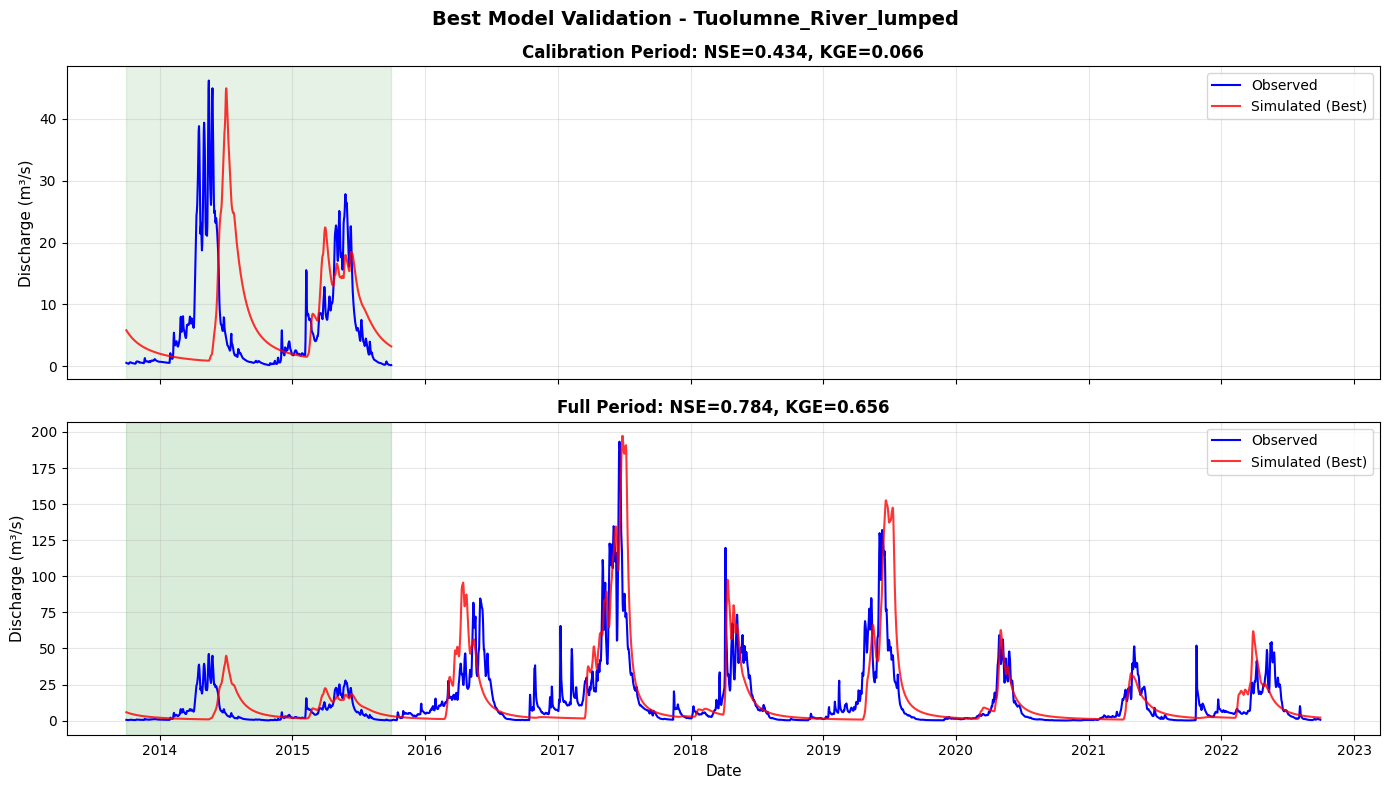

In [ ]:
    # Extract simulated streamflow
    shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    # Select the largest GRU_area (handles shapefiles with multiple features)
    if 'GRU_area' in shp_file.columns:
        shp_area = shp_file['GRU_area'].max()
    else:
        shp_area = 1.0

In [18]:
# Define paths
project_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}"
opt_trial_params = project_dir / "simulations" / "run_dds" / "settings" / "SUMMA" / "trialParams.nc"
main_trial_params = project_dir / "settings" / "SUMMA" / "trialParams.nc"

# Backup and copy
if opt_trial_params.exists():
    # Backup original
    if main_trial_params.exists():
        backup_path = main_trial_params.with_suffix('.nc.backup')
        shutil.copy(main_trial_params, backup_path)
        print(f"Backed up original to: {backup_path}")
    
    # Copy optimized parameters
    shutil.copy(opt_trial_params, main_trial_params)
    print(f"✅ Copied optimized parameters to: {main_trial_params}")
else:
    print(f"⚠️ Optimized parameters not found: {opt_trial_params}")


Backed up original to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/settings/SUMMA/trialParams.nc.backup
✅ Copied optimized parameters to: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/settings/SUMMA/trialParams.nc


In [19]:

# Now update the parameter files with best optimization values
update_results = confluence.managers['optimization'].update_parameters_with_best_values(
    backup_before_update=True,  # Creates .bak files as safety backup
    verbose=True
)

if update_results['success']:
    print(f"\n✓ Updated {update_results['local_params_updated']} local parameters")
    print(f"✓ Updated {update_results['basin_params_updated']} basin parameters")
    print("\n→ Parameters now formatted with exactly 4 decimal places")
    print("→ Values like 1.0838 (not 1.083789e+00) and 1.0000d-05 (not 1.000000e-05)")
else:
    print(f"✗ Update failed: {update_results.get('error', 'Unknown error')}")

2026-02-25 11:30:47 ● Using latest optimization results from: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/optimisation/dds_20260224_moreSpongy
2026-02-25 11:30:47 ● Updating parameter files with best values from: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/optimisation/dds_20260224_moreSpongy/best_parameters.csv
Parameter update summary:
  Local parameters updated: 5
  Basin parameters updated: 2

  Local parameters updated:
    k_soil: 9.845163260772307e-06
    theta_sat: 0.5972942228684617
    theta_res: 0.0635356603512979
    aquiferScaleFactor: 0.9031683082212244
    rootingDepth: 4.06642998615958

  Basin parameters updated:
    basin__aquiferScaleFactor: 17.057333734913644
    basin__aquiferHydCond: 2.8944861397201564
2026-02-25 11:30:47 ● Parameter files updated successfully with best optimization values

✓ Updated 5 local parameters
✓ Updated 2 basin parameters

→ Parameters now formatted with exactly 4 decimal places
→ Values like 1.0838 (

In [21]:
# Step 2: Reformat ALL parameter values to exactly 4 decimal places
# This ensures every single value (even non-calibrated ones) has consistent formatting
from utils.custom.adjust_settings import reformat_all_parameters

project_settings_dir = project_dir / "settings" / "SUMMA"
localParamInfo_file = project_settings_dir / "localParamInfo.txt"
basinParamInfo_file = project_settings_dir / "basinParamInfo.txt"

print("Reformatting ALL parameter values to exactly 4 decimal places...")
reformat_all_parameters(localParamInfo_file, verbose=True)
reformat_all_parameters(basinParamInfo_file, verbose=True)
print("\n✓ All parameters now have consistent 4-decimal formatting (1.2345 or 1.2345d-05)")

Reformatting ALL parameter values to exactly 4 decimal places...
Reformatted 0 parameter entries in localParamInfo.txt
Reformatted 0 parameter entries in basinParamInfo.txt

✓ All parameters now have consistent 4-decimal formatting (1.2345 or 1.2345d-05)


## Step 4b: Run model

In [19]:
# Ensure parameter snapshots are saved inside the experiment folder
experiment_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_updates['DOMAIN_NAME']}" / "simulations" / name
outputeControl_file = "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA/outputControl.txt"
parameters_dir = experiment_dir / "parameters"
parameters_dir.mkdir(parents=True, exist_ok=True)
shutil.copy(localParamInfo_file, parameters_dir / "localParamInfo.txt")
shutil.copy(basinParamInfo_file, parameters_dir / "basinParamInfo.txt")
shutil.copy(outputeControl_file, project_settings_dir / "outputControl.txt")

PosixPath('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/settings/SUMMA/outputControl.txt')

In [20]:
# =============================================================================
# NOW RUN THE MODEL
# =============================================================================

print("\n" + "="*60)
print("🚀 Running SUMMA model...")
print("="*60)

confluence.managers['model'].run_models()
print("✅ Basin-scale integrated simulation complete")


🚀 Running SUMMA model...
2026-02-25 12:42:05 ● Starting model runs
2026-02-25 12:42:05 ● Running model: SUMMA
2026-02-25 12:42:05 ● Starting SUMMA run
2026-02-25 12:44:51 ● SUMMA run completed successfully
✅ Basin-scale integrated simulation complete


## Step 5: Streamflow Evaluation and Basin Performance Assessment

/tmp/ipykernel_286708/672169358.py:95: RuntimeWarning: invalid value encountered in scalar divide
  obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])


/tmp/ipykernel_286708/672169358.py:95: RuntimeWarning: invalid value encountered in scalar divide
  obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])



=== TIMING DIAGNOSTICS ===
Mean timing offset: -6 days (negative = early)
Peak month: Obs=5, Sim=4
NSE (post spin-up): -0.782


/tmp/ipykernel_286708/672169358.py:95: RuntimeWarning: invalid value encountered in scalar divide
  obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])



=== TIMING DIAGNOSTICS ===
Mean timing offset: -6 days (negative = early)
Peak month: Obs=5, Sim=4
NSE (post spin-up): -0.782


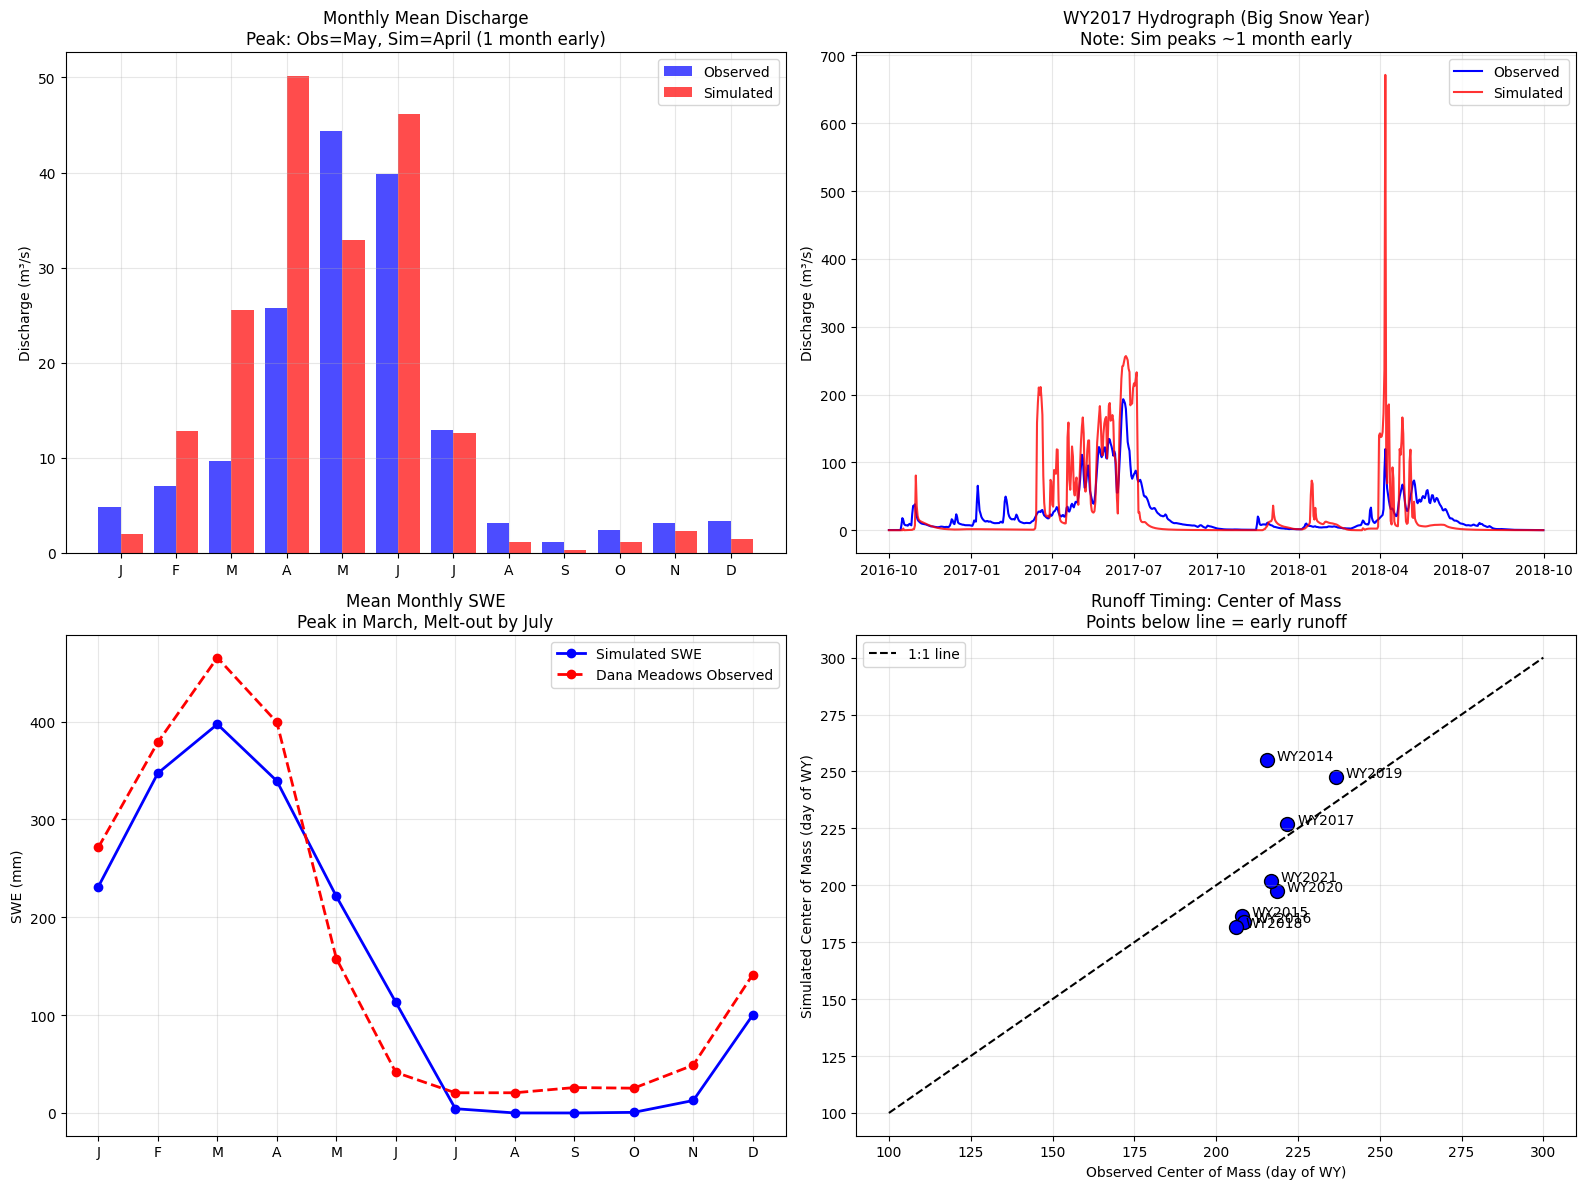

In [21]:
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
save = False

# Get basin area
shp_path = project_dir / "shapefiles" / "catchment" / "Tuolumne_River_lumped_HRUs_GRUs.shp"
gdf = gpd.read_file(shp_path).to_crs('EPSG:32611')
basin_area = gdf.geometry.area.sum()

# Calculate discharge
runoff = sim_ds['scalarTotalRunoff'].squeeze()
discharge = runoff * basin_area  # m³/s

# Load observations
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / "Tuolumne_River_lumped_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)

# Align to common period (skip first year for spin-up)
start = '2013-10-01'
end = '2022-09-30'
sim_daily = discharge.resample(time='D').mean().sel(time=slice(start, end))
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start:end]

# Create figure
fig = plt.figure(figsize=(16, 12))

# 1. Monthly climatology comparison
ax1 = fig.add_subplot(2, 2, 1)
sim_monthly = sim_daily.groupby('time.month').mean()
obs_monthly = obs_daily.groupby(obs_daily.index.month).mean()
months = range(1, 13)
ax1.bar([m-0.2 for m in months], [float(obs_monthly.loc[m]) for m in months], 
        width=0.4, label='Observed', color='blue', alpha=0.7)
ax1.bar([m+0.2 for m in months], [float(sim_monthly.sel(month=m)) for m in months], 
        width=0.4, label='Simulated', color='red', alpha=0.7)
ax1.set_xticks(months)
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.set_ylabel('Discharge (m³/s)')
ax1.set_title('Monthly Mean Discharge\nPeak: Obs=May, Sim=April (1 month early)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Water year 2017 (big snow year) hydrograph
ax2 = fig.add_subplot(2, 2, 2)
wy2017_sim = sim_daily.sel(time=slice('2016-10-01', '2018-09-30'))
wy2017_obs = obs_daily.loc['2016-10-01':'2018-09-30']
ax2.plot(wy2017_obs.index, wy2017_obs.values, 'b-', label='Observed', lw=1.5)
ax2.plot(pd.to_datetime(wy2017_sim.time.values), wy2017_sim.values, 'r-', label='Simulated', lw=1.5, alpha=0.8)
ax2.set_ylabel('Discharge (m³/s)')
ax2.set_title('WY2017 Hydrograph (Big Snow Year)\nNote: Sim peaks ~1 month early')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. SWE comparison with Tuolumne Meadows if available
ax3 = fig.add_subplot(2, 2, 3)
swe = sim_ds['scalarSWE'].squeeze().resample(time='D').mean()
tuolumne_meadows = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/snow/TUM_TUOLUMNE_MEADOWS_cdec_obs.csv", parse_dates=['datetime'], index_col='datetime')
tuolumne_meadows_swe = tuolumne_meadows['SWE']*25.4
# filter values 
# filter extreme values
tuolumne_meadows_swe = tuolumne_meadows_swe[(tuolumne_meadows_swe < 2000) & (tuolumne_meadows_swe >= 0)]
tuolumne_meadows_swe_monthly = tuolumne_meadows_swe.groupby(tuolumne_meadows_swe.index.month).mean()
# Plot multi-year average SWE cycle
swe_monthly = swe.sel(time=slice(start, end)).groupby('time.month').mean()
ax3.plot(months, [float(swe_monthly.sel(month=m)) for m in months], 'b-o', lw=2, label='Simulated SWE')
ax3.plot(months, tuolumne_meadows_swe_monthly.values, 'r--o', lw=2, label='Dana Meadows Observed')
ax3.set_xticks(months)
ax3.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax3.set_ylabel('SWE (mm)')
ax3.set_title('Mean Monthly SWE\nPeak in March, Melt-out by July')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Timing metrics by year
ax4 = fig.add_subplot(2, 2, 4)
timing_data = []
for year in range(2012, 2022):
    wy_start = f'{year-1}-10-01'
    wy_end = f'{year}-09-30'
    
    sim_wy = sim_daily.sel(time=slice(wy_start, wy_end))
    obs_wy = obs_daily.loc[wy_start:wy_end]
    
    # Find center of mass (timing metric)
    sim_vals = sim_wy.values
    obs_vals = obs_wy.values
    
    days = np.arange(len(sim_vals))
    if np.sum(sim_vals) > 0:
        sim_com = np.sum(days * sim_vals) / np.sum(sim_vals)
    else:
        sim_com = np.nan
        
    obs_com = np.sum(days * obs_vals[~np.isnan(obs_vals)]) / np.sum(obs_vals[~np.isnan(obs_vals)])
    
    timing_data.append({'year': year, 'sim_com': sim_com, 'obs_com': obs_com})

timing_df = pd.DataFrame(timing_data)
ax4.scatter(timing_df['obs_com'], timing_df['sim_com'], s=100, c='blue', edgecolor='black')
ax4.plot([100, 300], [100, 300], 'k--', label='1:1 line')
for _, row in timing_df.iterrows():
    ax4.annotate(f"WY{int(row['year'])}", (row['obs_com']+3, row['sim_com']))
ax4.set_xlabel('Observed Center of Mass (day of WY)')
ax4.set_ylabel('Simulated Center of Mass (day of WY)')
ax4.set_title('Runoff Timing: Center of Mass\nPoints below line = early runoff')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
if save:
    plt.savefig('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/plots/timing_diagnostic.png', dpi=150)
    print("Saved: timing_diagnostic.png")

# Print summary statistics
print("\n=== TIMING DIAGNOSTICS ===")
print(f"Mean timing offset: {float(timing_df['sim_com'].mean() - timing_df['obs_com'].mean()):.0f} days (negative = early)")
print(f"Peak month: Obs={obs_monthly.idxmax()}, Sim={int(sim_monthly.argmax())+1}")

# Calculate NSE excluding spin-up
common_idx = pd.to_datetime(sim_daily.time.values)
obs_aligned = obs_daily.reindex(common_idx)
valid = ~obs_aligned.isna()
sim_v = sim_daily.values[valid]
obs_v = obs_aligned.values[valid]
nse = 1 - np.sum((obs_v - sim_v)**2) / np.sum((obs_v - np.mean(obs_v))**2)
print(f"NSE (post spin-up): {nse:.3f}")

sim_ds.close()
plt.show()


 Streamflow Performance Assessment...
   Evaluation period: 2014-04-01 00:00:00 to 2022-09-30 23:00:00.000013312
   Duration: 3104 days
   Valid paired observations: 3105 days

📈 Streamflow Performance Metrics:
   📊 RMSE: 29.84 m³/s
   📊 Bias: +2.76 m³/s (+20.0%)
   📊 MAE: 14.01 m³/s
   📊 Correlation (r): 0.700
   📊 Nash-Sutcliffe (NSE): -0.809
   📊 Kling-Gupta (KGE): 0.093

🌊 Hydrologic Signature Analysis:
   High flows (Q95): Obs=55.1, Sim=111.5 m³/s
   Low flows (Q05): Obs=0.3, Sim=0.0 m³/s
   Peak flow timing: Obs=Month 5, Sim=Month 4



 Streamflow Performance Assessment...
   Evaluation period: 2014-04-01 00:00:00 to 2022-09-30 23:00:00.000013312
   Duration: 3104 days
   Valid paired observations: 3105 days

📈 Streamflow Performance Metrics:
   📊 RMSE: 29.84 m³/s
   📊 Bias: +2.76 m³/s (+20.0%)
   📊 MAE: 14.01 m³/s
   📊 Correlation (r): 0.700
   📊 Nash-Sutcliffe (NSE): -0.809
   📊 Kling-Gupta (KGE): 0.093

🌊 Hydrologic Signature Analysis:
   High flows (Q95): Obs=55.1, Sim=111.5 m³/s
   Low flows (Q05): Obs=0.3, Sim=0.0 m³/s
   Peak flow timing: Obs=Month 5, Sim=Month 4


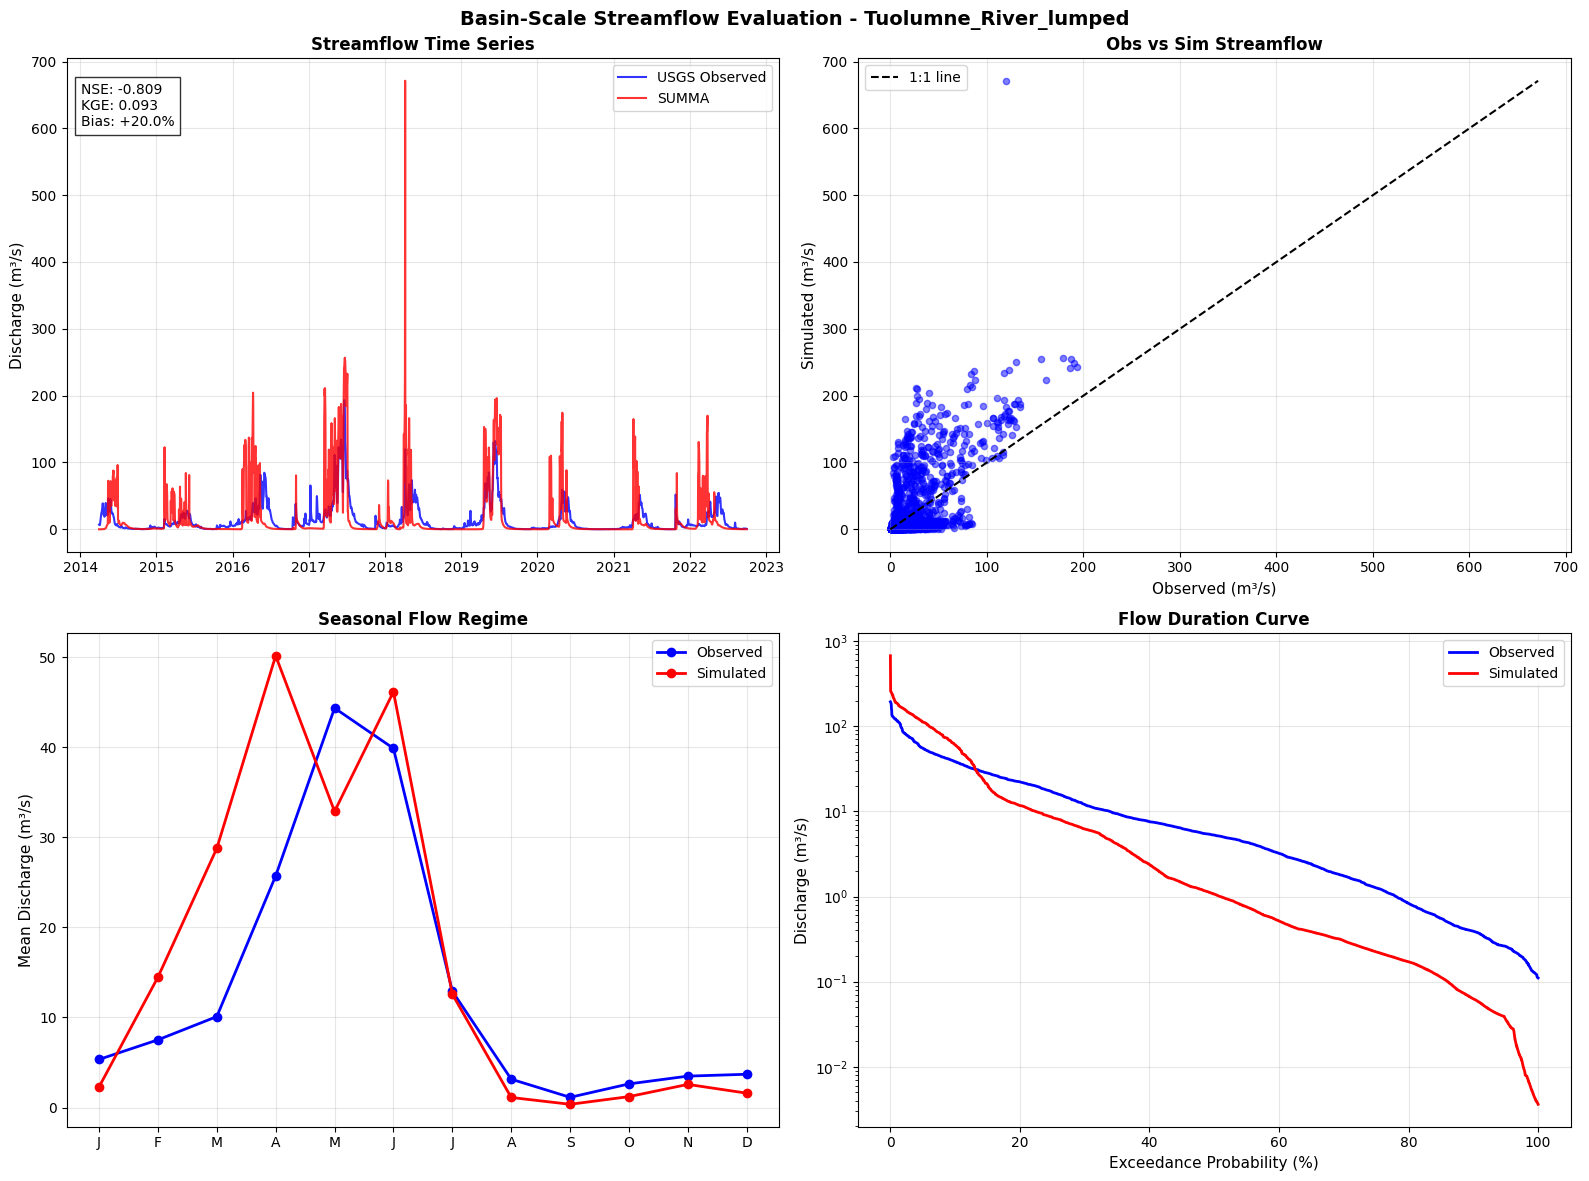

In [29]:
# Load observed streamflow data
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)
    
# Load simulated streamflow from mizuRoute
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
routing_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))

if routing_files:
    # Load mizuRoute output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract streamflow variable (typically IRFroutedRunoff)
    
    sim_streamflow = routing_ds['IRFroutedRunoff']
    sim_df = sim_streamflow.to_pandas()    
    routing_ds.close()

else:
    sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
    shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    shp_area = shp_file['GRU_area'].values[1]
    sim_ds['scalarTotalRunoff'] = sim_ds['scalarTotalRunoff'] * shp_area
    sim_streamflow = sim_ds['scalarTotalRunoff']    
    sim_df = sim_streamflow.to_pandas()
    # Calculate discharge
    
    sim_ds.close()

# =============================================================================
# STREAMFLOW PERFORMANCE EVALUATION
# =============================================================================

print(f"\n Streamflow Performance Assessment...")

# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

print(f"   Evaluation period: {start_date} to {end_date}")
print(f"   Duration: {(end_date - start_date).days} days")

# Filter to common period and resample to daily
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Ensure sim_daily is a Series (in case it's a DataFrame with one column)
if isinstance(sim_daily, pd.DataFrame):
    if sim_daily.shape[1] == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Take the first (and likely only) column
    else:
        print(f"⚠️  sim_daily has {sim_daily.shape[1]} columns. Using the first column.")
        print(f"   Available columns: {list(sim_daily.columns)}")
        sim_daily = sim_daily.iloc[:, 0]

# Remove any remaining NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]    
print(f"   Valid paired observations: {len(obs_valid)} days")

# Calculate comprehensive performance metrics
print(f"\n📈 Streamflow Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()

# Relative metrics
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency  
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# Hydrologic signature analysis
print(f"\n🌊 Hydrologic Signature Analysis:")

# Flow statistics
obs_q95 = obs_valid.quantile(0.95)  # High flows
sim_q95 = sim_valid.quantile(0.95)
obs_q05 = obs_valid.quantile(0.05)  # Low flows  
sim_q05 = sim_valid.quantile(0.05)

print(f"   High flows (Q95): Obs={obs_q95:.1f}, Sim={sim_q95:.1f} m³/s")
print(f"   Low flows (Q05): Obs={obs_q05:.1f}, Sim={sim_q05:.1f} m³/s")

# Seasonal timing
obs_monthly = obs_valid.groupby(obs_valid.index.month).mean()
sim_monthly = sim_valid.groupby(sim_valid.index.month).mean()
peak_month_obs = obs_monthly.idxmax()
peak_month_sim = sim_monthly.idxmax()

print(f"   Peak flow timing: Obs=Month {peak_month_obs}, Sim=Month {peak_month_sim}")

# =============================================================================
# STREAMFLOW VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-', 
         label='USGS Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-', 
         label='SUMMA', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Streamflow Time Series', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim Streamflow', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

ax3.plot(months, obs_monthly.values, 'o-', label='Observed', 
         color='blue', linewidth=2, markersize=6)
ax3.plot(months, sim_monthly.values, 'o-', label='Simulated', 
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Simulated', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Basin-Scale Streamflow Evaluation - {config_dict["DOMAIN_NAME"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Water Balance Components

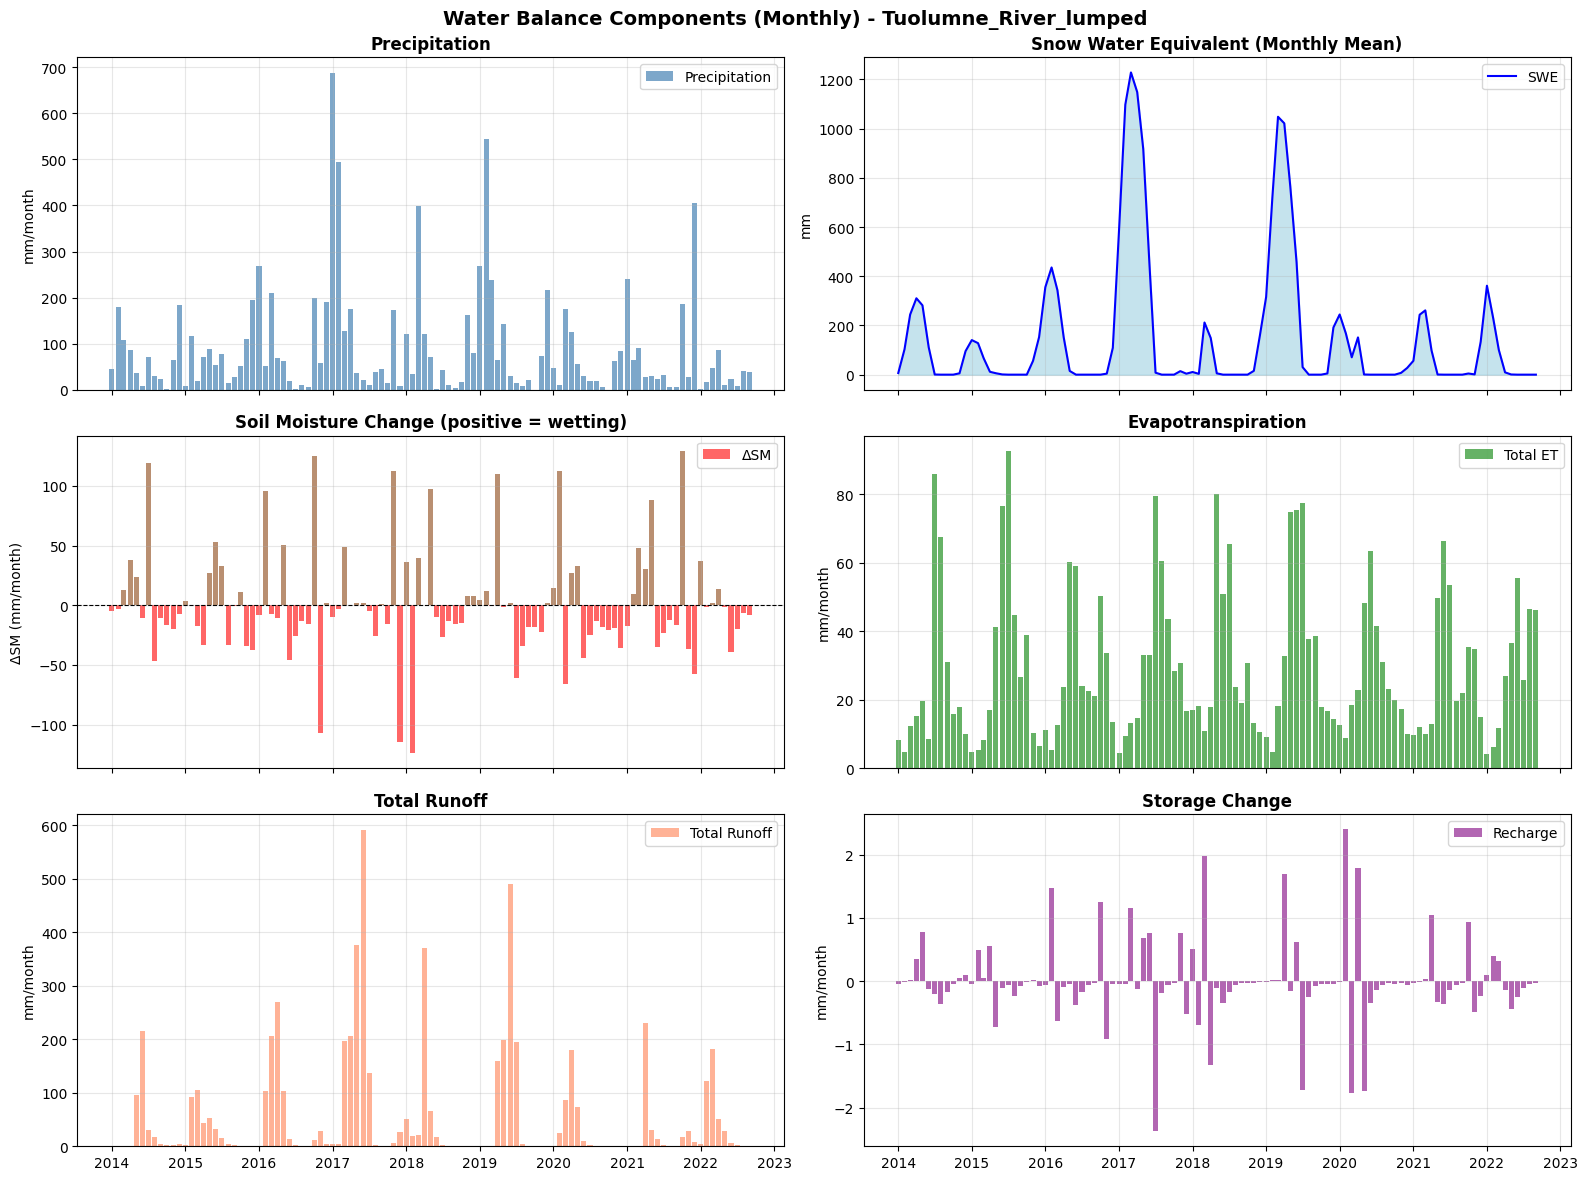

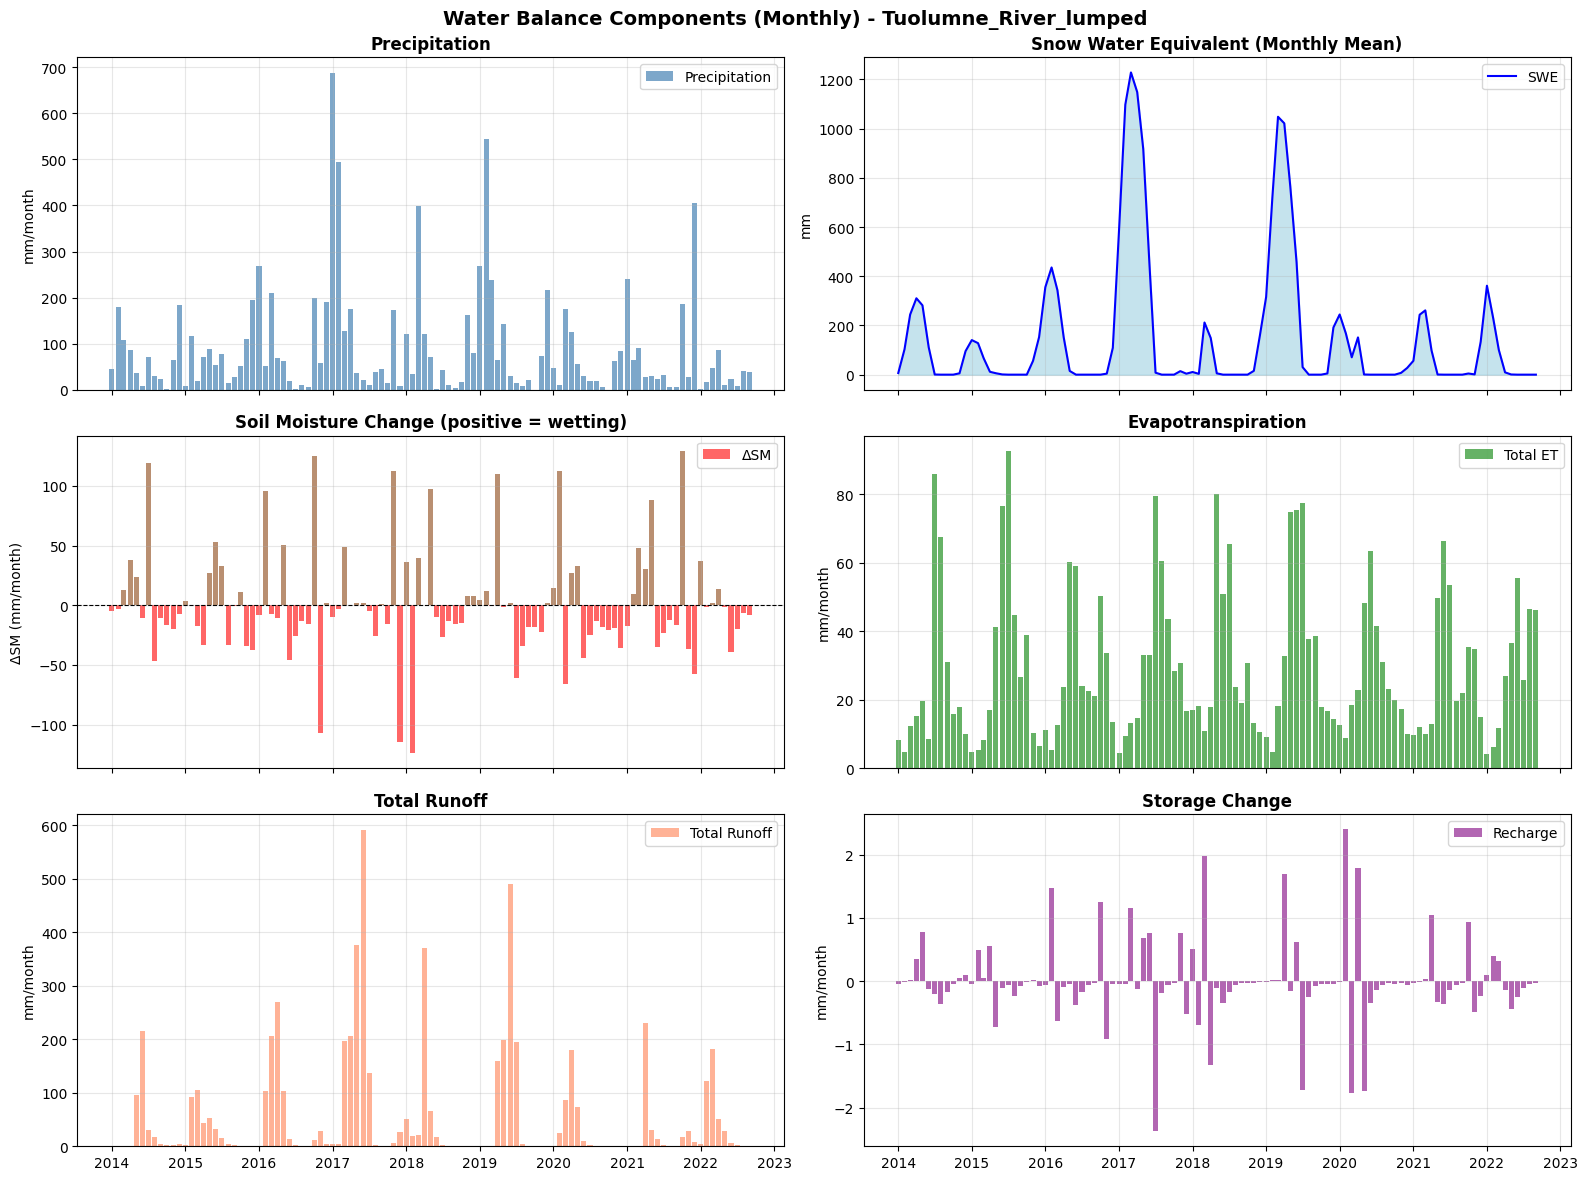

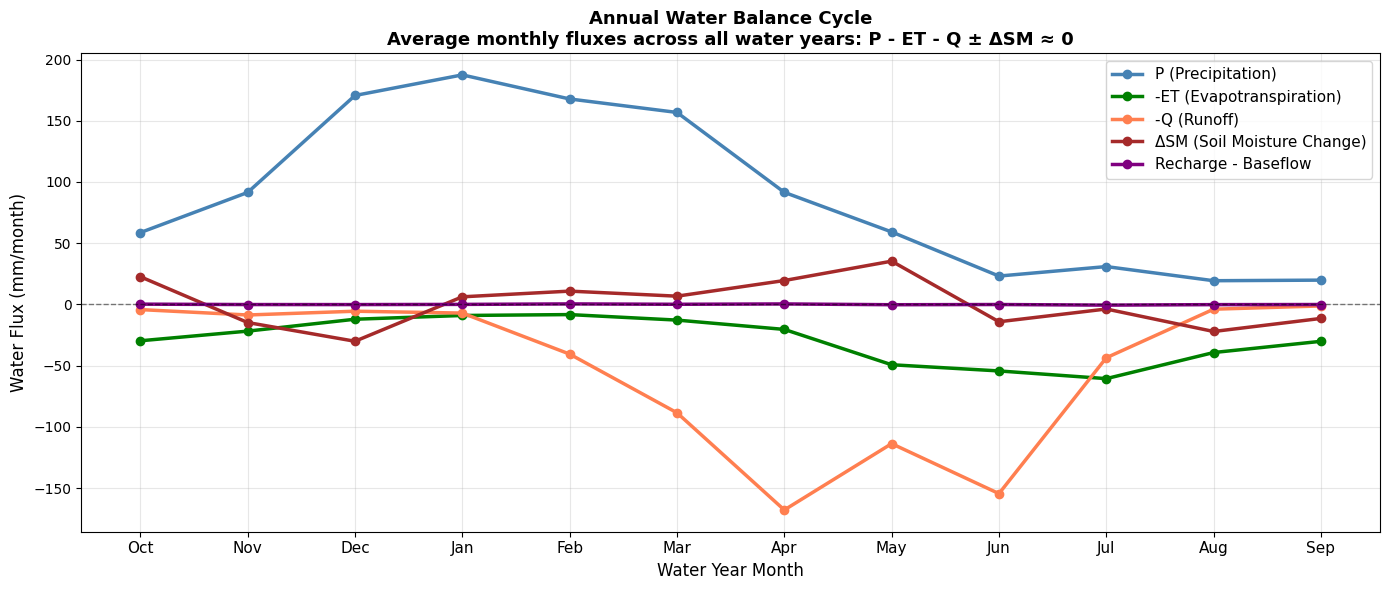


ANNUAL WATER BALANCE SUMMARY (mm/year)
 Year      P (mm)     ET (mm)      Q (mm)   ΔSM (mm)  Peak SWE (mm)
 2014  838.183451 -296.555846  368.847077  75.279843     310.447257
 2015  832.655096 -372.367180  355.246542 -28.985752     152.568843
 2016 1146.215630 -336.922483  745.955974  41.137884     435.729496
 2017 1830.295658 -366.584467 1552.290993  -7.287149    1228.506490
 2018 1062.934971 -357.072460  551.495106 -14.829496     211.953086
 2019 1620.967054 -417.911351 1052.940062 -26.452980    1048.306008
 2020  631.674385 -316.838613  377.881199 -53.459093     244.627408
 2021 1138.558674 -340.779156  330.619015 107.515449     261.273477
 2022  270.154667 -259.153594  397.845058 -24.076739     361.478375

--------------------------------------------------------------------------------
Mean Annual P:    1041.3 mm
Mean Annual ET:   -340.5 mm
Mean Annual Q:     637.0 mm
Mean Annual ΔSM:     7.6 mm

Water Balance Closure: Q - P + ET - ΔSM = -56.2 mm/year
(Residual represents general 

In [30]:
# =============================================================================
# WATER BALANCE COMPONENT TIMESERIES - MONTHLY TOTALS
# =============================================================================
import matplotlib.dates as mdates

# Load SUMMA output for water balance analysis
summa_file = list(summa_dir.glob("*.nc"))
if summa_file:
    ds_wb = xr.open_dataset(summa_file[0])
    ds_wb = ds_wb.sel(time=slice('2014-01-01', '2022-09-30'))  # Focus on common period
    
    # Extract time and convert to pandas datetime
    time_wb = pd.to_datetime(ds_wb['time'].values)
    
    # Initialize monthly series
    monthly_precip = None
    monthly_swe = None
    monthly_delta_sm = None
    monthly_et = None
    monthly_runoff = None
    monthly_recharge = None
    
    # 1. Precipitation (convert from kg/m2/s to mm/month via daily totals)
    if 'pptrate' in ds_wb:
        precip = ds_wb['pptrate'].values.squeeze() * 86400 / 24  # kg/m2/s to mm/day
        precip_daily = pd.Series(precip, index=time_wb)
        monthly_precip = precip_daily.resample('MS').sum()  # Monthly total
    
    # 2. SWE (keep as daily mean for end-of-month values, kg/m2 = mm)
    if 'scalarSWE' in ds_wb:
        swe_wb = ds_wb['scalarSWE'].values.squeeze()
        swe_daily = pd.Series(swe_wb, index=time_wb)
        monthly_swe = swe_daily.resample('MS').mean()  # Monthly mean for visualization
    
    # 3. Soil Moisture Change (Delta SM in mm/month)
    if 'scalarTotalSoilLiq' in ds_wb:
        soil_liq = ds_wb['scalarTotalSoilLiq'].values.squeeze()  # kg/m2 = mm
        soil_daily = pd.Series(soil_liq, index=time_wb)
        # Calculate monthly change: SM_end - SM_start for each month
        monthly_delta_sm = soil_daily.resample('MS').last() - soil_daily.resample('MS').first()
    
    # 4. Evapotranspiration (convert from W/m2 to mm/month)
    latent_heat_vap = 2.45e6  # J/kg
    if 'scalarTotalET' in ds_wb:
        et = ds_wb['scalarTotalET'].values.squeeze()  # kg/m2/s -> mm/day
        et_mm_day = et * 86400 / 24  # Convert to mm/day
        et_daily = pd.Series(et_mm_day, index=time_wb)
        monthly_et = et_daily.resample('MS').sum()  # Monthly total
    elif 'scalarLatHeatTotal' in ds_wb:
        et_wm2 = ds_wb['scalarLatHeatTotal'].values.squeeze()  # W m-2
        et_mm_day = et_wm2 * 86400 / 24 / latent_heat_vap
        et_daily = pd.Series(et_mm_day, index=time_wb)
        monthly_et = et_daily.resample('MS').sum()  # Monthly total
    
    # 5. Runoff (convert from m/s to mm/month)
    if 'scalarTotalRunoff' in ds_wb:
        runoff_wb = ds_wb['scalarTotalRunoff'].values.squeeze() * 86400 / 24 * 1000  # m/s to mm/day
        runoff_daily = pd.Series(runoff_wb, index=time_wb)
        monthly_runoff = runoff_daily.resample('MS').sum()  # Monthly total
    
    # 6. Storage change (Recharge - Baseflow) (convert from m/s to mm/month)
    if 'scalarAquiferRecharge' in ds_wb:
        recharge = ds_wb['scalarAquiferRecharge'].values.squeeze() * 86400 / 24 * 1000  # m/s to mm/day
        baseflow = ds_wb['scalarAquiferBaseflow'].values.squeeze() * 86400 / 24 * 1000  # m/s to mm/day
        delta_storage_daily = pd.Series(recharge-baseflow, index=time_wb)
        monthly_delta_storage = delta_storage_daily.resample('MS').sum()  # Monthly total
    
    # =============================================================================
    # VISUALIZATION: PANEL PLOTS
    # =============================================================================
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    axes = axes.flatten()
    
    # 1. Precipitation
    ax = axes[0]
    if monthly_precip is not None:
        ax.bar(monthly_precip.index, monthly_precip.values, width=25, color='steelblue', alpha=0.7, label='Precipitation')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Precipitation', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 2. SWE (daily mean)
    ax = axes[1]
    if monthly_swe is not None:
        ax.fill_between(monthly_swe.index, monthly_swe.values, color='lightblue', alpha=0.7)
        ax.plot(monthly_swe.index, monthly_swe.values, color='blue', linewidth=1.5, label='SWE')
        ax.set_ylabel('mm', fontsize=10)
        ax.set_title('Snow Water Equivalent (Monthly Mean)', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 3. Soil Moisture Change (Delta SM)
    ax = axes[2]
    if monthly_delta_sm is not None:
        colors = ['red' if x < 0 else 'saddlebrown' for x in monthly_delta_sm.values]
        ax.bar(monthly_delta_sm.index, monthly_delta_sm.values, width=25, color=colors, alpha=0.6, label='ΔSM')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel('ΔSM (mm/month)', fontsize=10)
        ax.set_title('Soil Moisture Change (positive = wetting)', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 4. Evapotranspiration
    ax = axes[3]
    if monthly_et is not None:
        ax.bar(monthly_et.index, (-monthly_et).values.clip(min=0), width=25, color='green', alpha=0.6, label='Total ET')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Evapotranspiration', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 5. Runoff
    ax = axes[4]
    if monthly_runoff is not None:
        ax.bar(monthly_runoff.index, monthly_runoff.values, width=25, color='coral', alpha=0.6, label='Total Runoff')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Total Runoff', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 6. Recharge
    ax = axes[5]
    if monthly_delta_storage is not None:
        ax.bar(monthly_delta_storage.index, monthly_delta_storage.values, width=25, color='purple', alpha=0.6, label='Recharge')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Storage Change', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # Format x-axis
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
    
    plt.suptitle(f'Water Balance Components (Monthly) - {config_dict["DOMAIN_NAME"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
        # =============================================================================
    # WATER BALANCE TIME SERIES - ANNUAL CYCLE (Monthly averages across all years)
    # =============================================================================
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Calculate monthly averages across all water years
    months = range(1, 13)
    month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
    
    # Group by water year month (Oct=1, Nov=2, ..., Sep=12)
    monthly_precip_cycle = monthly_precip.groupby(monthly_precip.index.month).mean()
    monthly_et_cycle = monthly_et.groupby(monthly_et.index.month).mean()
    monthly_runoff_cycle = monthly_runoff.groupby(monthly_runoff.index.month).mean()
    monthly_delta_sm_cycle = monthly_delta_sm.groupby(monthly_delta_sm.index.month).mean()
    monthly_delta_storage_cycle = monthly_delta_storage.groupby(monthly_delta_storage.index.month).mean()
    
    
    # Reorder to water year (Oct-Sep instead of Jan-Dec)
    wy_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Water year months
    wy_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
    
    # Reorder the data
    if monthly_precip is not None:
        precip_wy = [monthly_precip_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), precip_wy, 'o-', label='P (Precipitation)', 
                color='steelblue', linewidth=2.5, markersize=6)
    
    if monthly_et is not None:
        et_wy = [monthly_et_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), et_wy, 'o-', label='-ET (Evapotranspiration)', 
                color='green', linewidth=2.5, markersize=6)
    
    if monthly_runoff is not None:
        runoff_wy = [-monthly_runoff_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), runoff_wy, 'o-', label='-Q (Runoff)', 
                color='coral', linewidth=2.5, markersize=6)
    if monthly_delta_sm_cycle is not None:
        delta_sm_wy = [monthly_delta_sm_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), delta_sm_wy, 'o-', label='ΔSM (Soil Moisture Change)', 
                color='brown', linewidth=2.5, markersize=6)
        
    if monthly_delta_storage_cycle is not None:
        delta_storage_wy = [monthly_delta_storage_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), delta_storage_wy, 'o-', label='Recharge - Baseflow', 
                color='purple', linewidth=2.5, markersize=6)
    
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xticks(range(12))
    ax.set_xticklabels(wy_labels, fontsize=11)
    ax.set_ylabel('Water Flux (mm/month)', fontsize=12)
    ax.set_xlabel('Water Year Month', fontsize=12)
    ax.set_title('Annual Water Balance Cycle\nAverage monthly fluxes across all water years: P - ET - Q ± ΔSM ≈ 0', 
                 fontweight='bold', fontsize=13)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # ANNUAL WATER BALANCE SUMMARY
    # =============================================================================
    
    print("\n" + "=" * 80)
    print("ANNUAL WATER BALANCE SUMMARY (mm/year)")
    print("=" * 80)
    
    # Calculate annual totals
    annual_summary = []
    years = monthly_precip.index.year.unique()
    for year in years:
        year_mask = monthly_precip.index.year == year
        annual = {
            'Year': year,
            'P (mm)': monthly_precip[year_mask].sum() if monthly_precip is not None else np.nan,
            'ET (mm)': monthly_et[year_mask].sum() if monthly_et is not None else np.nan,
            'Q (mm)': monthly_runoff[year_mask].sum() if monthly_runoff is not None else np.nan,
            'ΔSM (mm)': monthly_delta_sm[year_mask].sum() if monthly_delta_storage is not None else np.nan,
            'Peak SWE (mm)': monthly_swe[year_mask].max() if monthly_swe is not None else np.nan,
        }
        annual_summary.append(annual)
    
    annual_df = pd.DataFrame(annual_summary)
    print(annual_df.to_string(index=False))
    
    # Water balance closure
    print("\n" + "-" * 80)
    print(f"Mean Annual P:   {annual_df['P (mm)'].mean():7.1f} mm")
    print(f"Mean Annual ET:  {annual_df['ET (mm)'].mean():7.1f} mm")
    print(f"Mean Annual Q:   {annual_df['Q (mm)'].mean():7.1f} mm")
    print(f"Mean Annual ΔSM: {annual_df['ΔSM (mm)'].mean():7.1f} mm")
    
    # Closure check
    imbalance = annual_df['Q (mm)'].mean() - annual_df['P (mm)'].mean() - annual_df['ET (mm)'].mean() + annual_df['ΔSM (mm)'].mean()
    print(f"\nWater Balance Closure: Q - P + ET - ΔSM = {imbalance:.1f} mm/year")
    print("(Residual represents general storage changes.)")
    
    ds_wb.close()
else:
    print("No SUMMA output file found!")

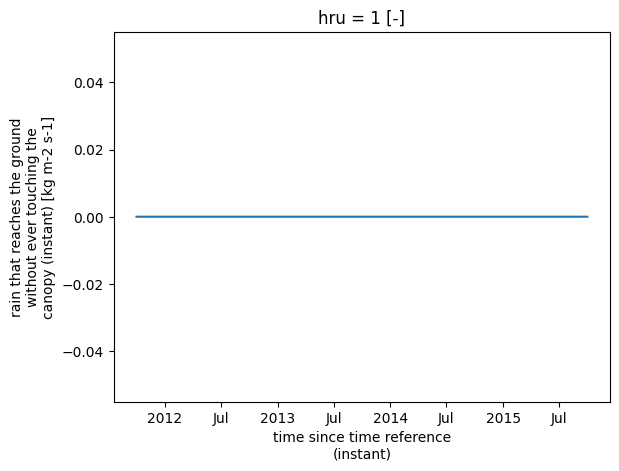

In [67]:
ds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/simulations/run_dds/SUMMA/run_dds_opt_20260224_moreSpongy_timestep.nc")
(ds['scalarThroughfallRain']).plot()

### ET evaluation

In [31]:
sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
open_et = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/et/openet_et_ensemble_tuolumne_monthly.csv", index_col=0, parse_dates=True)

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


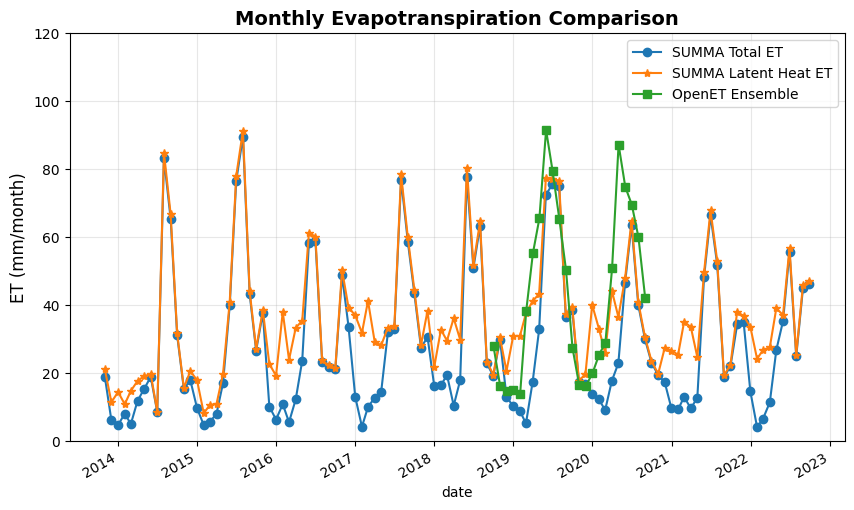

In [32]:
et = sim_ds['scalarLatHeatTotal'].resample(time='ME').mean().sel(time=slice('2013-10-01', '2022-09-30'))
total_et = sim_ds['scalarTotalET'].resample(time='ME').mean().sel(time=slice('2013-10-01', '2022-09-30'))
# convert to kg/m2/s to mm/month
latent_heat = -et * 30 * 24 * 3600 / 2.45e6
total_et = -total_et * 30*24*3600
fig, ax = plt.subplots(figsize=(10, 6))
total_et.plot(ax=ax, label='SUMMA Total ET', marker='o')
latent_heat.plot(ax=ax, label='SUMMA Latent Heat ET', marker='*')
open_et['et'].plot(ax=ax, label='OpenET Ensemble', marker='s')
ax.set_ylabel('ET (mm/month)', fontsize=12)
ax.set_title('Monthly Evapotranspiration Comparison', fontweight='bold', fontsize=14)
ax.legend()
ax.set_ylim(0,120)
ax.grid(True, alpha=0.3)

### Temperature Evaluation

In [68]:
tuolumne_meadows = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/snow/TUM_TUOLUMNE_MEADOWS_cdec_obs.csv", parse_dates=['datetime'], index_col='datetime')
tuolumne_meadows = tuolumne_meadows.loc['2014-01-01':'2022-01-01']

Monthly bias (SUMMA - TUOLUMNE MEADOWS): [-0.02041125 -0.37786803 -0.85201505 -1.29905311 -0.87350013  0.36692344
  1.24565403  1.57042775  1.73733429  1.2767319   0.43483919  0.16881337]


Monthly bias (SUMMA - TUOLUMNE MEADOWS): [-0.02041125 -0.37786803 -0.85201505 -1.29905311 -0.87350013  0.36692344
  1.24565403  1.57042775  1.73733429  1.2767319   0.43483919  0.16881337]


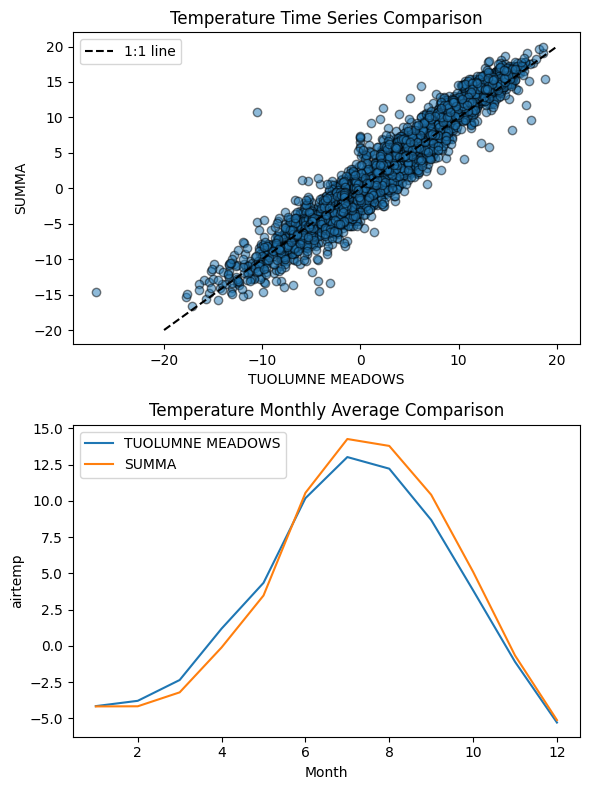

In [92]:
tuolumne_meadows_temp =((tuolumne_meadows['AIR TEMP'] - 32) * 5/9)
tuolumne_meadows_temp = tuolumne_meadows_temp[(tuolumne_meadows_temp > -50) & (tuolumne_meadows_temp < 50)]
tuolumne_meadows_temp_monthly = tuolumne_meadows_temp.groupby(tuolumne_meadows_temp.index.month).mean()

sim_ds_airtemp = sim_ds['airtemp'].resample(time='D').mean().sel(time=tuolumne_meadows_temp.index.date).squeeze() - 273.16
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,8))
axs[0].scatter(tuolumne_meadows_temp.values, sim_ds_airtemp.values, alpha=0.5, ec='k')
axs[0].plot([-20,20], [-20,20], 'k--', label='1:1 line')
axs[0].legend()
axs[0].set_xlabel('TUOLUMNE MEADOWS')
axs[0].set_ylabel('SUMMA')
axs[0].set_title("Temperature Time Series Comparison")

# plot monthly average comparison
tuolumne_meadows_temp_monthly.plot(ax=axs[1], label='TUOLUMNE MEADOWS')
sim_ds_airtemp.groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("Temperature Monthly Average Comparison")

print(f"Monthly bias (SUMMA - TUOLUMNE MEADOWS): {(sim_ds_airtemp.groupby('time.month').mean() - tuolumne_meadows_temp_monthly).values}")

### SWE evaluation

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'SWE Monthly Average Comparison')

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'SWE Monthly Average Comparison')

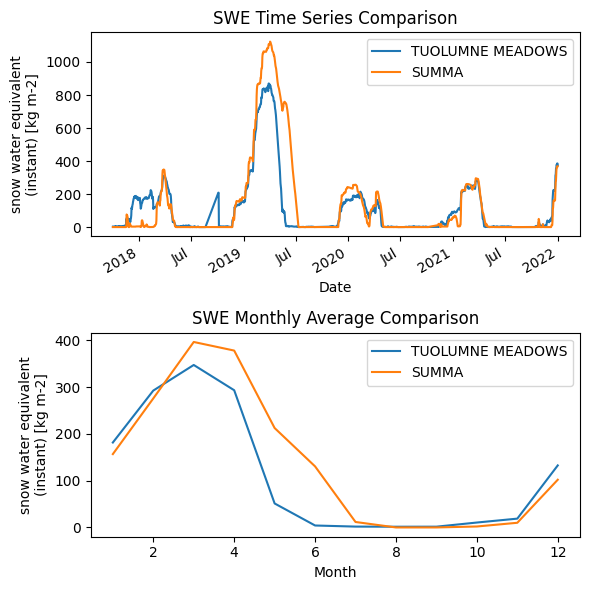

In [76]:
tuolumne_meadows_swe = tuolumne_meadows['SWE']*25.4
# filter extreme values
tuolumne_meadows_swe = tuolumne_meadows_swe[(tuolumne_meadows_swe < 2000) & (tuolumne_meadows_swe >= 0)].loc["2017-10-01":"2022-01-01"]
tuolumne_meadows_swe_monthly = tuolumne_meadows_swe.groupby(tuolumne_meadows_swe.index.month).mean()
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,6))
tuolumne_meadows_swe.plot(ax=axs[0], label='TUOLUMNE MEADOWS')
sim_ds.sel(time=tuolumne_meadows_swe.index.date)['scalarSWE'].plot(ax=axs[0], label='SUMMA')
axs[0].legend()
axs[0].set_xlabel('Date')
axs[0].set_title("SWE Time Series Comparison")

# plot monthly average comparison
tuolumne_meadows_swe_monthly.plot(ax=axs[1], label='TUOLUMNE MEADOWS')
sim_ds.sel(time=tuolumne_meadows_swe.index.date)['scalarSWE'].groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("SWE Monthly Average Comparison")

### Precipitation Evaluation

In [90]:
# convert to 1d array
d = (sim_ds['pptrate'].sel(time=slice('2014-01-01', '2021-12-31')).resample(time='1D').mean()*3600*24).groupby('time.month').sum()
d_1d = d.values.flatten()
d_1d

array([1685.50443649, 1494.03891563, 1364.04662132,  738.65418434,
        522.65396118,  185.88910103,  269.76628304,  134.66706276,
        140.08126259,  469.39558983,  731.68730736, 1365.10019302])

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'Precipitation Annual Cycle (Bar Plot)')

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'Precipitation Annual Cycle (Bar Plot)')

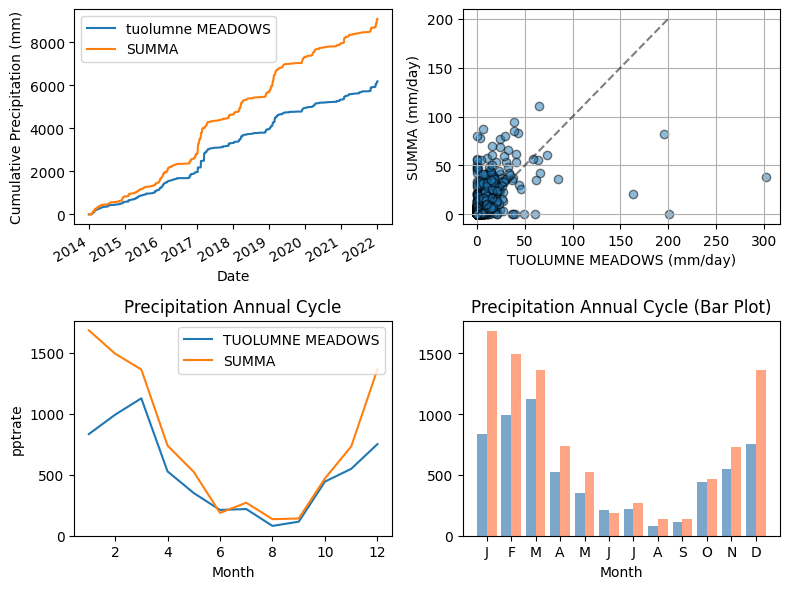

In [91]:
tuolumne_meadows_ppt = (tuolumne_meadows['PRECIPITATION']*25.4)
tuolumne_meadows_ppt = tuolumne_meadows_ppt[tuolumne_meadows_ppt < 500]
fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(8,6), tight_layout=True)
axs=axs.flatten()

tuolumne_meadows_ppt.cumsum().plot(ax=axs[0], label='tuolumne MEADOWS')
(sim_ds.sel(time=slice('2014-01-01', '2021-12-31'))['pptrate']*3600).cumsum().plot(ax=axs[0], label='SUMMA')
axs[0].legend()
axs[0].set_title("")
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Cumulative Precipitation (mm)')

# add 1:1 line scatter plot
axs[1].scatter(tuolumne_meadows_ppt.values, (sim_ds['pptrate'].resample(time='1D').mean()*3600*24).sel(time=tuolumne_meadows_ppt.index.date).values, alpha=0.5, ec='k')
axs[1].plot([0, 200], [0, 200], 'k--', alpha=0.5)
axs[1].grid()
axs[1].set_xlabel('TUOLUMNE MEADOWS (mm/day)')
axs[1].set_ylabel('SUMMA (mm/day)')

# add annual cycle line plots
tuolumne_meadows_ppt.groupby(tuolumne_meadows_ppt.index.month).sum().plot(ax=axs[2], label='TUOLUMNE MEADOWS')
(sim_ds['pptrate'].sel(time=slice('2014-01-01', '2021-12-31')).resample(time='1D').mean()*3600*24).groupby('time.month').sum().plot(ax=axs[2], label='SUMMA')
axs[2].legend()
axs[2].set_xlabel('Month')
axs[2].set_title("Precipitation Annual Cycle")

# overlaying barplots of annual cycle
months = range(1, 13)
axs[3].bar(months, tuolumne_meadows_ppt.groupby(tuolumne_meadows_ppt.index.month).sum().values, width=0.4, label='TUOLUMNE MEADOWS', color='steelblue', alpha=0.7)  
axs[3].bar([m+0.4 for m in months], (sim_ds['pptrate'].sel(time=slice('2014-01-01', '2021-12-31')).resample(time='1D').mean()*3600*24).groupby('time.month').sum().values.flatten(), width=0.4, label='SUMMA', color='coral', alpha=0.7)
axs[3].set_xticks([m+0.2 for m in months])
axs[3].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
axs[3].set_xlabel('Month')
axs[3].set_title("Precipitation Annual Cycle (Bar Plot)")

## Summary: Lumped Basin-Scale Streamflow Simulation
This tutorial successfully demonstrated the critical scaling transition from point-scale process validation to basin-scale integrated streamflow simulation using CONFLUENCE. Through the Tuolumne River at Yosemite case study, we illustrated how the same standardized workflow framework seamlessly scales from individual site validation to watershed-scale prediction while maintaining scientific rigor and computational efficiency.

## Key Methodological Achievements
The tutorial established watershed-scale modeling capabilities by successfully transitioning from point measurements to integrated basin response through automated watershed delineation and lumped representation strategies. Spatial aggregation techniques were demonstrated through catchment-averaged characteristic development that captures essential watershed properties while maintaining computational tractability. Integrated process simulation was achieved by coupling SUMMA's process-based physics with mizuRoute streamflow routing to transform distributed runoff generation into streamflow predictions at the basin outlet.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to simulate integrated watershed response through the successful representation of snow accumulation, melt, and runoff generation processes across elevation gradients in a mountain environment. Seasonal flow regime capture was validated through comparison with long-term Water Survey of Canada observations, showing the model's capability to represent pronounced spring freshet patterns and low-flow periods. Water balance closure was maintained through conservation of mass principles while scaling from point processes to basin-integrated streamflow generation.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless scaling capabilities by applying identical workflow principles from point validation through basin-scale prediction without requiring fundamental architectural changes. The model-agnostic preprocessing approach proved equally effective for basin-averaged forcing and validation data preparation, reinforcing the framework's broad applicability. Computational efficiency was demonstrated through lumped representation strategies that enable rapid execution suitable for calibration, uncertainty analysis, and operational applications while maintaining process-based physical realism.

This foundation in lumped basin modeling establishes the essential principles for understanding watershed-scale hydrological behavior and 
prepares for the spatial complexity introduced in semi-distributed and fully distributed modeling approaches in subsequent tutorials.

### Next Focus: Semi-Distributed Watershed Modelling 

**Ready to explore Semi-Distributed basin simulations?** → **[Tutorial 02b: Basin Scale - Semi-Distributed Watershed](./02b_basin_semi_distributed.ipynb)**